# **ANÁLISIS PREDICTIVO DEL TIEMPO DE TRÁNSITO DE LOS BUQUES EN EL CANAL DE PANAMÁ**


El objetivo central de este proyecto es desarrollar un modelo capaz de predecir con precisión el tiempo de tránsito de los buques, permitiendo una optimización proactiva de la logística interoceánica.

Para lograrlo, el notebook consolida un ecosistema de datos multidimensional que incluye:



*  El registro histórico de tránsitos y tiempos de espera (**transit.parquet**).
*  La trazabilidad operativa en las esclusas (**locks_visit.parquet**).
*  Las características técnicas y estructurales de las embarcaciones (**specs.parquet**).
*   Un conjunto de variables meteorológicas críticas (**clima_total_2015_2024**).

Al cruzar estos datasets, buscamos identificar cómo factores como el tipo de buque, su carga y las condiciones de viento y presión afectan la fluidez del paso, transformando datos históricos en una herramienta de inteligencia predictiva para la toma de decisiones.

## **EXTRACCIÓN Y LIMPIEZA DE DATOS**

Lo primero que haremos es extraer y convertir los datos de cada uno de los archivos en formato parquet a dataframes funcionales.

### **Transformación de los archivos de formato parquet a dataframes**

In [ ]:
import pandas as pd
import os

# Definimos los archivos que se leerán
specific_files = ['locks_visit.parquet', 'specs.parquet', 'transit.parquet']

# Inicializa un diccionario para almacenar los dataframes
dataframes = {}

# Lee cada archivo específico en un DataFrame
for fname in specific_files:
    file_path = os.path.join('/content/', fname)
    df = None

    try:
        # Intenta leer el archivo como Parquet
        df = pd.read_parquet(file_path)
        print(f"Archivo: {fname} leído como Parquet.")
    except Exception as e:
        print(f"Error al leer {fname} como Parquet: {e}")

    if df is not None:
        # Almacena el DataFrame en el diccionario
        dataframes[fname.replace('.parquet', '').replace('.csv', '')] = df

        # Muestra las primeras filas para confirmación
        display(df.head())

# Accedemos a los dataframes por sus nombres
locks_df = dataframes['locks_visit']
specs_df = dataframes['specs']
transit_df = dataframes['transit']

Archivo: locks_visit.parquet leído como Parquet.


,imo,mmsi,dt_pos_utc,Name,segr
0,2051.0,374001000.0,2019-01-01 00:00:00,Miraflores Locks Original,0
1,9534810.0,370313000.0,2019-01-01 00:00:20,Cocoli Locks,0
2,9377248.0,636013816.0,2019-01-01 00:00:55,Miraflores Locks Original,0
3,9397858.0,477133300.0,2019-01-01 00:01:05,Pedro Miguel Locks Original,0
4,9279989.0,352983000.0,2019-01-01 00:06:12,Cocoli Locks,0


Archivo: specs.parquet leído como Parquet.


,imo,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,1000021,68.500,1980,484,3716.0,Oil,Yacht
1,1000150,41.930,291,0,397.0,Oil,Yacht (Sailing)
2,1001178,49.580,702,0,2700.0,Oil,Yacht
3,1002225,30.800,397,387,756.0,Oil,Yacht
4,1002342,38.625,489,0,1156.0,Oil,Yacht


Archivo: transit.parquet leído como Parquet.


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
0,9717292.0,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111
1,9581239.0,1,South,Bulk carrier,2019-01-01 00:39:05,2019-01-02 02:41:17,2018-12-31 00:11:14,2018-12-31 23:09:29,0,22.970833,26.036667
2,9758038.0,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000
3,9369095.0,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167
4,9683398.0,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833


### **Transformación del archivo de clima csv a dataframe**

In [ ]:
import pandas as pd
import os

clima_df = pd.read_csv("/content/climate_vars_new.csv", encoding='latin1', sep=';')
display(clima_df.head())

,time,temperature_2m (°C),precipitation (mm),dew_point_2m (°C),relative_humidity_2m (%),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h)
0,2019-01-01T00:00,24.5,0.0,22.8,91,42,18,13,28,NaN,0.29,11.5,346,23.4
1,2019-01-01T01:00,24.5,0.0,22.6,89,61,14,5,53,NaN,0.32,12.1,348,25.2
2,2019-01-01T02:00,24.5,0.0,22.5,89,67,13,0,61,NaN,0.35,12.9,347,27.0
3,2019-01-01T03:00,24.5,0.0,22.2,87,74,28,0,64,NaN,0.40,12.8,350,27.0
4,2019-01-01T04:00,24.6,0.0,22.3,87,83,42,1,71,NaN,0.40,12.1,348,26.3


In [ ]:
display(df.head())

,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
0,9717292.0,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111
1,9581239.0,1,South,Bulk carrier,2019-01-01 00:39:05,2019-01-02 02:41:17,2018-12-31 00:11:14,2018-12-31 23:09:29,0,22.970833,26.036667
2,9758038.0,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000
3,9369095.0,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167
4,9683398.0,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833


### **Transformación del archivo del los niveles del lago gatun de csv a dataframe**

In [ ]:
gatun_level_df = pd.read_csv('/content/hystoric_water_level_gatun.csv', sep=';')
display(gatun_level_df.head())

,DATE_LOG,GATUN_LAKE_LEVEL(FEET)
0,01/01/1965,86.49
1,01/02/1965,86.48
2,01/03/1965,86.47
3,01/04/1965,86.46
4,01/05/1965,86.42


### **Limpieza de datos de los dataframes**


#### **Limpieza de SPECS_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11793 entries, 0 to 11792
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11793 non-null  int64  
 1   LengthBetweenPerpendicularsLBP  11793 non-null  float64
 2   GrossTonnage                    11793 non-null  int64  
 3   Deadweight                      11793 non-null  int64  
 4   Powerkwmax                      11787 non-null  float64
 5   MainEngineType                  11789 non-null  object 
 6   ShiptypeLevel5                  11793 non-null  object 
dtypes: float64(2), int64(3), object(2)
memory usage: 645.1+ KB


In [ ]:
print('Tipos de datos:')
display(specs_df.dtypes)

Tipos de datos:


,0
imo,int64
LengthBetweenPerpendicularsLBP,float64
GrossTonnage,int64
Deadweight,int64
Powerkwmax,float64
MainEngineType,object
ShiptypeLevel5,object


In [ ]:
# Transformamos la variable imo a string debido a que es un código y no un número
specs_df["imo"] = specs_df["imo"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna:')
display(specs_df.isnull().sum())

Valores nulos por columna:


,0
imo,0
LengthBetweenPerpendicularsLBP,0
GrossTonnage,0
Deadweight,0
Powerkwmax,6
MainEngineType,4
ShiptypeLevel5,0


Observamos los valores nulos en las columnas ***Powerkwmax*** y ***MainEngineType***. Vamos a trabjar en estrategías de imputación para ambos campos.

##### **Imputación de valores para MainEngineType**

Para este caso, vamos a utilizar 2 estrategías de imputación:

*  Primero, para cada valor de ShiptypeLevel5, calcularemos cuál es el MainEngineType más frecuente (la moda) dentro de ese tipo de buque y usaremos ese valor para rellenar solo los nulos de ese mismo grupo.

* Después, cualquier fila que siga nula (por ejemplo, porque en su grupo no había datos válidos para calcular moda) se eliminará.

In [ ]:
# Imputar valores nulos en MainEngineType con la moda por ShiptypeLevel5
def imputar_moda_engine_type(df):
    df = df.copy()
    for shiptype in df['ShiptypeLevel5'].unique():
        mask = (df['ShiptypeLevel5'] == shiptype)
        moda = df.loc[mask, 'MainEngineType'].mode(dropna=True)
        if not moda.empty:
            df.loc[mask & df['MainEngineType'].isnull(), 'MainEngineType'] = moda[0]
    return df

specs_df = imputar_moda_engine_type(specs_df)

# Eliminar registros que aún tengan MainEngineType nulo después de la imputación
specs_df = specs_df[~specs_df['MainEngineType'].isnull()].reset_index(drop=True)

# Verificar que ya no hay nulos en MainEngineType
display(specs_df['MainEngineType'].isnull().sum())

np.int64(0)

##### **Imputación de valores para Powerkwmax**

En este caso, vamos a buscar la media del grupo más específico (MainEngineType + ShiptypeLevel5) y, si no existe suficiente dato en ese cruce, cae a una media más general solo por ShiptypeLevel5.

In [ ]:
# Imputar valores nulos en Powerkwmax
import numpy as np

def imputar_media_powerkwmax(df):
    df = df.copy()
    mask_nulo = df['Powerkwmax'].isnull()
    for idx in df[mask_nulo].index:
        engine = df.at[idx, 'MainEngineType']
        shiptype = df.at[idx, 'ShiptypeLevel5']
        # Media por MainEngineType y ShiptypeLevel5
        media1 = df[(df['MainEngineType'] == engine) & (df['ShiptypeLevel5'] == shiptype)]['Powerkwmax'].mean()
        if not np.isnan(media1):
            df.at[idx, 'Powerkwmax'] = media1
        else:
            # Media por ShiptypeLevel5
            media2 = df[df['ShiptypeLevel5'] == shiptype]['Powerkwmax'].mean()
            if not np.isnan(media2):
                df.at[idx, 'Powerkwmax'] = media2
    return df

specs_df = imputar_media_powerkwmax(specs_df)

# Confirmar que no quedan nulos en Powerkwmax
display(specs_df['Powerkwmax'].isnull().sum())

np.int64(0)

In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11791 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11791 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11791 non-null  float64
 2   GrossTonnage                    11791 non-null  int64  
 3   Deadweight                      11791 non-null  int64  
 4   Powerkwmax                      11791 non-null  float64
 5   MainEngineType                  11791 non-null  object 
 6   ShiptypeLevel5                  11791 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 644.9+ KB


In [ ]:
specs_df

,imo,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,1000021,68.500,1980,484,3716.0,Oil,Yacht
1,1000150,41.930,291,0,397.0,Oil,Yacht (Sailing)
2,1001178,49.580,702,0,2700.0,Oil,Yacht
3,1002225,30.800,397,387,756.0,Oil,Yacht
4,1002342,38.625,489,0,1156.0,Oil,Yacht
...,...,...,...,...,...,...,...
11786,9965851,196.800,36091,64611,7080.0,Oil,Bulk Carrier
11787,9966087,197.000,36412,64028,6940.0,Oil,Bulk Carrier
11788,9966104,178.000,24386,40020,5650.0,Oil,Bulk Carrier
11789,9973420,174.000,23759,37359,5400.0,Oil,Bulk Carrier


In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11791 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11791 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11791 non-null  float64
 2   GrossTonnage                    11791 non-null  int64  
 3   Deadweight                      11791 non-null  int64  
 4   Powerkwmax                      11791 non-null  float64
 5   MainEngineType                  11791 non-null  object 
 6   ShiptypeLevel5                  11791 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 644.9+ KB


##### **Limpieza de outliers**

Limpiaremos los outliers; comenzaremos eliminando aquellos valores negativos o cero (0) de las variables:

* ***LengthBetweenPerpendicularsLBP***
* ***GrossTonnage***
* ***Deadweight***
* ***Powerkwmax***

Estas variables representan medidas físicas del buque o de su capacidad y, por lógica operativa, no deberían ser 0 si el registro corresponde a una embarcación real en servicio.

In [ ]:
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

# Eliminar valores no válidos: 0 o negativos
specs_df = specs_df[
    (specs_df["LengthBetweenPerpendicularsLBP"] > 0) &
    (specs_df["GrossTonnage"] > 0) &
    (specs_df["Deadweight"] > 0) &
    (specs_df["Powerkwmax"] > 0)
].copy()

print("Filas luego de eliminar 0 y negativos:", len(specs_df))

Filas luego de eliminar 0 y negativos: 11522


Ahora procedemos a detectar y eliminar las variables de las outliers utilizando el metodo de IQR para cada una de las columnas previamente vistas.

In [ ]:
print('Valores mínimos y máximos de las variables seleccionadas:')
print(f"LengthBetweenPerpendicularsLBP: Min = {specs_df['LengthBetweenPerpendicularsLBP'].min()}, Max = {specs_df['LengthBetweenPerpendicularsLBP'].max()}")
print(f"GrossTonnage: Min = {specs_df['GrossTonnage'].min()}, Max = {specs_df['GrossTonnage'].max()}")
print(f"Deadweight: Min = {specs_df['Deadweight'].min()}, Max = {specs_df['Deadweight'].max()}")
print(f"Powerkwmax: Min = {specs_df['Powerkwmax'].min()}, Max = {specs_df['Powerkwmax'].max()}")

print('\nLímites Inferiores y Superiores (IQR):')
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

for col in cols:
    Q1 = specs_df[col].quantile(0.25)
    Q3 = specs_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}: Inferior = {lower_bound:.2f}, Superior = {upper_bound:.2f}")

Valores mínimos y máximos de las variables seleccionadas:
LengthBetweenPerpendicularsLBP: Min = 16.6, Max = 383.0
GrossTonnage: Min = 56, Max = 203949
Deadweight: Min = 4, Max = 398199
Powerkwmax: Min = 228.0, Max = 80905.0

Límites Inferiores y Superiores (IQR):
LengthBetweenPerpendicularsLBP: Inferior = 97.00, Superior = 297.00
GrossTonnage: Inferior = -9203.62, Superior = 76307.38
Deadweight: Inferior = -35707.12, Superior = 137855.88
Powerkwmax: Inferior = -1175.00, Superior = 21105.00


In [ ]:
cols_with_bounds = {
    "GrossTonnage": {"lower": -9203.62, "upper": 76307.38},
    "Deadweight": {"lower": -35707.12, "upper": 137855.88},
    "Powerkwmax": {"lower": -1175.00, "upper": 21105.00}
}

total_lost_rows = 0
print("Número de filas fuera de los límites para cada variable:")
for col, bounds in cols_with_bounds.items():
    lower = bounds["lower"]
    upper = bounds["upper"]
    lost_for_col = specs_df[(specs_df[col] < lower) | (specs_df[col] > upper)].shape[0]
    print(f"- {col}: {lost_for_col} filas perdidas")
    total_lost_rows += lost_for_col

print(f"\nTotal de filas perdidas fuera de los límites especificados: {total_lost_rows}")

Número de filas fuera de los límites para cada variable:
- GrossTonnage: 1257 filas perdidas
- Deadweight: 495 filas perdidas
- Powerkwmax: 1469 filas perdidas

Total de filas perdidas fuera de los límites especificados: 3221


In [ ]:
specs_df.describe()

,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax
count,11522.000000,11522.000000,11522.000000,11522.000000
mean,191.666255,38761.368946,54002.619511,13500.887612
std,57.241560,28239.268301,37817.574599,13570.132027
min,16.600000,56.000000,4.000000,228.000000
25%,172.000000,22863.000000,29379.000000,7180.000000
50%,185.000000,32287.000000,49999.000000,8990.000000
75%,222.000000,44240.750000,72769.750000,12750.000000
max,383.000000,203949.000000,398199.000000,80905.000000


In [ ]:
print('\nLímites Inferiores y Superiores (IQR):')
cols = ["LengthBetweenPerpendicularsLBP", "GrossTonnage", "Deadweight", "Powerkwmax"]

for col in cols:
    Q1 = specs_df[col].quantile(0.25)
    Q3 = specs_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}: Inferior = {lower_bound:.2f}, Superior = {upper_bound:.2f}")


Límites Inferiores y Superiores (IQR):
LengthBetweenPerpendicularsLBP: Inferior = 97.00, Superior = 297.00
GrossTonnage: Inferior = -9203.62, Superior = 76307.38
Deadweight: Inferior = -35707.12, Superior = 137855.88
Powerkwmax: Inferior = -1175.00, Superior = 21105.00


In [ ]:
# cols = ["GrossTonnage", "Deadweight", "Powerkwmax"]
# min_obs = 30

# rows_to_drop = []
# summary = []

# keep_mask = pd.Series(True, index=specs_df.index)

# for col in cols:
#     Q1 = specs_df[col].quantile(0.25)
#     Q3 = specs_df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     keep_mask &= specs_df[col].between(lower, upper, inclusive="both")

# removed = (~keep_mask).sum()
# rows_to_drop.extend(specs_df.index[~keep_mask].tolist())
# summary.append(("total", len(specs_df), int(removed), "procesado"))

# specs_df_no_outliers = specs_df.drop(index=rows_to_drop).copy()

# summary_df = pd.DataFrame(summary, columns=["grupo", "n_grupo", "filas_eliminadas", "estado"])

# display(summary_df.sort_values("filas_eliminadas", ascending=False))

# print("Filas originales:", len(specs_df))
# print("Filas sin outliers:", len(specs_df_no_outliers))
# print("Filas eliminadas:", len(specs_df) - len(specs_df_no_outliers))

In [ ]:
# specs_df = specs_df_no_outliers

In [ ]:
specs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11522 entries, 0 to 11790
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   imo                             11522 non-null  object 
 1   LengthBetweenPerpendicularsLBP  11522 non-null  float64
 2   GrossTonnage                    11522 non-null  int64  
 3   Deadweight                      11522 non-null  int64  
 4   Powerkwmax                      11522 non-null  float64
 5   MainEngineType                  11522 non-null  object 
 6   ShiptypeLevel5                  11522 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 720.1+ KB


#### **Limpieza de TRANSIT_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
transit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50933 entries, 0 to 50932
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   imo                 50920 non-null  float64       
 1   neo_transit         50933 non-null  int64         
 2   transit_bound       50933 non-null  object        
 3   vessel_type         50933 non-null  object        
 4   time_at_entrance    50933 non-null  datetime64[us]
 5   time_out_canal      50927 non-null  datetime64[us]
 6   time_anchoring_in   48952 non-null  datetime64[us]
 7   time_anchoring_out  48952 non-null  datetime64[us]
 8   direct_transit      50933 non-null  int32         
 9   waiting_time        48952 non-null  float64       
 10  transit_time        50927 non-null  float64       
dtypes: datetime64[us](4), float64(3), int32(1), int64(1), object(2)
memory usage: 4.1+ MB


In [ ]:
transit_df.describe()

,imo,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
count,5.092000e+04,50933.000000,50933,50927,48952,48952,50933.000000,48952.000000,50927.000000
mean,9.508686e+06,0.258300,2021-06-12 07:59:29.622072,2021-06-12 17:13:20.113162,2021-05-13 00:57:06.410708,2021-05-14 17:41:17.395857,0.505095,40.736385,11.141819
min,1.000021e+06,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:29,2018-12-31 22:35:13,0.000000,0.000000,-117.793611
25%,9.339334e+06,0.000000,2020-03-08 17:17:20,2020-03-09 03:07:10,2020-02-19 04:18:50.500000,2020-02-21 07:09:49.750000,0.000000,8.500000,7.350278
50%,9.515932e+06,0.000000,2021-05-28 05:42:26,2021-05-28 15:12:42,2021-04-23 03:14:13.500000,2021-04-24 05:46:53.500000,1.000000,21.475000,8.533889
75%,9.730878e+06,1.000000,2022-10-18 23:32:41,2022-10-19 06:01:13.500000,2022-08-12 02:10:00,2022-08-13 22:07:30,1.000000,48.666667,10.646389
max,9.974589e+06,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,1880.833333,2961.572222
std,3.655298e+05,0.437704,NaN,NaN,NaN,NaN,0.499979,55.972301,22.982345


In [ ]:
print('Tipos de datos:')
display(transit_df.dtypes)

Tipos de datos:


,0
imo,float64
neo_transit,int64
transit_bound,object
vessel_type,object
time_at_entrance,datetime64[us]
time_out_canal,datetime64[us]
time_anchoring_in,datetime64[us]
time_anchoring_out,datetime64[us]
direct_transit,int32
waiting_time,float64


In [ ]:
# Transformamos la variable imo a string debido a que es un codigo y no un número
transit_df["imo"] = transit_df["imo"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna:')
display(transit_df.isnull().sum())

Valores nulos por columna:


,0
imo,0
neo_transit,0
transit_bound,0
vessel_type,0
time_at_entrance,0
time_out_canal,6
time_anchoring_in,1981
time_anchoring_out,1981
direct_transit,0
waiting_time,1981


##### **Eliminación de valores nulos para waiting_time, imo o transit_time nulos**

Eliminamos los valores de imo, waiting_time y transit_time nulos debido a que las cantidades son poco significativas en comparación de la totalidad de los datos (solamente representan 3% de la totalidad de datos).

In [ ]:
# Eliminar registros con waiting_time, imo o transit_time nulos
transit_df = transit_df[
    transit_df["waiting_time"].notna() &
    transit_df["imo"].notna() &
    transit_df["transit_time"].notna()
].copy()

# Verificación
print("Filas restantes:", len(transit_df))
print("Nulos en waiting_time:", transit_df["waiting_time"].isna().sum())
print("Nulos en imo:", transit_df["imo"].isna().sum())
print("Nulos en transit_time:", transit_df["transit_time"].isna().sum())

Filas restantes: 48950
Nulos en waiting_time: 0
Nulos en imo: 0
Nulos en transit_time: 0


In [ ]:
print(f"Valor mínimo de waiting_time: {transit_df['waiting_time'].min():.2f} horas")
print(f"Valor mínimo de transit_time: {transit_df['transit_time'].min():.2f} horas")

Valor mínimo de waiting_time: 0.00 horas
Valor mínimo de transit_time: 4.19 horas


##### **Manejo de outliers**

Manejamos los outliers de waiting_time y transit_time con el método de IQR. Aquellos valores que estén por encima de los límites, se eliminan.

In [ ]:
# Eliminar outliers superiores en waiting_time y transit_time con método IQR (1.5)
cols_outliers = ["waiting_time", "transit_time"]

keep_mask = pd.Series(True, index=transit_df.index)
resumen = []

for col in cols_outliers:
    q1 = transit_df[col].quantile(0.25)
    q3 = transit_df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr

    # 1. Conservar solo los elementos menores o iguales al límite superior
    mask_col = transit_df[col] <= upper
    keep_mask &= mask_col

    resumen.append({
        "columna": col,
        "q1": q1,
        "q3": q3,
        "limite_superior": upper,
        "outliers_columna": int((~mask_col).sum())  # Outliers detectados en ESTA columna
    })

transit_df_no_outliers = transit_df.loc[keep_mask].copy()
transit_df = transit_df_no_outliers  # Sobrescribe el dataset limpio

display(pd.DataFrame(resumen))
print(f"Filas originales: {len(keep_mask)}")
print(f"Filas sin outliers: {len(transit_df)}")
print(f"Total de filas eliminadas (combinado): {int((~keep_mask).sum())}\n")

# 2. Imprimir de forma separada los outliers de waiting_time y transit_time
print("--- Detalle de elementos eliminados por superar el límite superior ---")
for r in resumen:
    print(f"Eliminados en '{r['columna']}': {r['outliers_columna']}")

,columna,q1,q3,limite_superior,outliers_columna
0,waiting_time,8.500000,48.666667,108.916667,4732
1,transit_time,7.314444,10.481250,15.231458,7112


Filas originales: 48950
Filas sin outliers: 38491
Total de filas eliminadas (combinado): 10459

--- Detalle de elementos eliminados por superar el límite superior ---
Eliminados en 'waiting_time': 4732
Eliminados en 'transit_time': 7112


In [ ]:
print(f"Valor mínimo de waiting_time: {transit_df['waiting_time'].min():.2f} horas")
print(f"Valor mínimo de transit_time: {transit_df['transit_time'].min():.2f} horas")

Valor mínimo de waiting_time: 0.00 horas
Valor mínimo de transit_time: 4.19 horas


In [ ]:
# Validamos el dataframe
transit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38491 entries, 0 to 50932
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   imo                 38491 non-null  object        
 1   neo_transit         38491 non-null  int64         
 2   transit_bound       38491 non-null  object        
 3   vessel_type         38491 non-null  object        
 4   time_at_entrance    38491 non-null  datetime64[us]
 5   time_out_canal      38491 non-null  datetime64[us]
 6   time_anchoring_in   38491 non-null  datetime64[us]
 7   time_anchoring_out  38491 non-null  datetime64[us]
 8   direct_transit      38491 non-null  int32         
 9   waiting_time        38491 non-null  float64       
 10  transit_time        38491 non-null  float64       
dtypes: datetime64[us](4), float64(2), int32(1), int64(1), object(3)
memory usage: 3.4+ MB


In [ ]:
transit_df.describe()

,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time
count,38491.000000,38491,38491,38491,38491,38491.000000,38491.000000,38491.000000
mean,0.206646,2021-04-25 02:48:14.720454,2021-04-25 11:19:36.859811,2021-04-23 22:06:41.583019,2021-04-25 00:07:36.039359,0.505859,26.015127,8.522816
min,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:40,2018-12-31 22:35:13,0.000000,0.000000,4.190556
25%,0.000000,2020-02-01 03:28:58,2020-02-01 09:34:33.500000,2020-01-30 16:29:41.500000,2020-01-31 19:40:52,0.000000,7.822917,7.134861
50%,0.000000,2021-03-30 14:06:57,2021-03-30 23:10:29,2021-03-29 16:48:03,2021-03-30 10:34:08,1.000000,18.510000,8.119722
75%,0.000000,2022-07-23 07:16:32.500000,2022-07-23 15:27:19.500000,2022-07-22 01:55:00,2022-07-23 02:00:00,1.000000,36.333333,9.311389
max,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,108.910000,15.230556
std,0.404904,NaN,NaN,NaN,NaN,0.499972,24.307843,1.959347


#### **Limpieza de LOCKS_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
locks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1226806 entries, 0 to 1226805
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   imo         497268 non-null   float64
 1   mmsi        1226323 non-null  float64
 2   dt_pos_utc  1226806 non-null  object 
 3   Name        1226806 non-null  object 
 4   segr        1226806 non-null  int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 46.8+ MB


In [ ]:
print('Tipos de datos:')
display(locks_df.dtypes)


Tipos de datos:


,0
imo,float64
mmsi,float64
dt_pos_utc,object
Name,object
segr,int64


In [ ]:
# Transformamos la variable imo a string debido a que es un código y no un número
locks_df["imo"] = locks_df["imo"].astype("Int64").astype(str)
locks_df["mmsi"] = locks_df["mmsi"].astype("Int64").astype(str)

##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna antes de la eliminación:')
display(locks_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


,0
imo,0
mmsi,0
dt_pos_utc,0
Name,0
segr,0


##### **Eliminamos los valores nulos de imo y mmsi**

Eliminamos los registros donde imo y mmsi son nulos debido a que estos registros son únicos.

In [ ]:
# Eliminar filas donde 'imo' es null
locks_df = locks_df.dropna(subset=['imo'])
locks_df = locks_df.dropna(subset=['mmsi'])

print('\nValores nulos por columna después de eliminar nulos en imo:')
display(locks_df.isnull().sum())



Valores nulos por columna después de eliminar nulos en imo:


,0
imo,0
mmsi,0
dt_pos_utc,0
Name,0
segr,0


#### **Limpieza de CLIMA_DF**

##### **Revisamos los distintos tipos de datos**

In [ ]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   time                           43824 non-null  object 
 1   temperature_2m (°C)            43824 non-null  float64
 2   precipitation (mm)             43824 non-null  float64
 3   dew_point_2m (°C)              43824 non-null  float64
 4   relative_humidity_2m (%)       43824 non-null  int64  
 5   cloud_cover (%)                43824 non-null  int64  
 6   cloud_cover_low (%)            43824 non-null  int64  
 7   cloud_cover_mid (%)            43824 non-null  int64  
 8   cloud_cover_high (%)           43824 non-null  int64  
 9   visibility (m)                 24341 non-null  float64
 10  vapour_pressure_deficit (kPa)  43824 non-null  float64
 11  wind_speed_10m (km/h)          43824 non-null  float64
 12  wind_direction_10m (°)         43824 non-null 

In [ ]:
print('Tipos de datos:')
display(clima_df.dtypes)


Tipos de datos:


,0
time,object
temperature_2m (°C),float64
precipitation (mm),float64
dew_point_2m (°C),float64
relative_humidity_2m (%),int64
cloud_cover (%),int64
cloud_cover_low (%),int64
cloud_cover_mid (%),int64
cloud_cover_high (%),int64
visibility (m),float64


##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna antes de la eliminación:')
display(clima_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


,0
time,0
temperature_2m (°C),0
precipitation (mm),0
dew_point_2m (°C),0
relative_humidity_2m (%),0
cloud_cover (%),0
cloud_cover_low (%),0
cloud_cover_mid (%),0
cloud_cover_high (%),0
visibility (m),19483


 ##### **Transformamos los datos de las columnas para facilidad de análisis**

Se realiza una estandarización del conjunto climático para asegurar consistencia antes del análisis: primero, se unifica la nomenclatura renombrando la columna año a periodo cuando está presente, luego se normalizan los nombres de todas las variables a minúsculas para evitar errores por diferencias de formato y, finalmente, se crea una copia operativa del dataset (clima) que será utilizada en las etapas posteriores.

In [ ]:
# Renombrar la columna "año" a "periodo"
if "año" in clima_df.columns:
    clima_df.rename(columns={"año": "periodo"}, inplace=True)

if "año" in clima_df.columns:
    clima_df.rename(columns={"año": "periodo"}, inplace=True)
    # Convertir todas las columnas a minúsculas
    clima_df.columns = clima_df.columns.str.lower()

    # Asignar clima_df a clima para usarlo en celdas posteriores
    clima = clima_df.copy()
# Convertir todas las columnas a minúsculas (siempre)
clima_df.columns = clima_df.columns.str.lower()

# Asignar clima_df normalizado a clima
clima = clima_df.copy()

print("Columnas en clima:", clima.columns.tolist())
print("Columnas en clima_df:", clima_df.columns.tolist())

Columnas en clima: ['time', 'temperature_2m (°c)', 'precipitation (mm)', 'dew_point_2m (°c)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'visibility (m)', 'vapour_pressure_deficit (kpa)', 'wind_speed_10m (km/h)', 'wind_direction_10m (°)', 'wind_gusts_10m (km/h)']
Columnas en clima_df: ['time', 'temperature_2m (°c)', 'precipitation (mm)', 'dew_point_2m (°c)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'visibility (m)', 'vapour_pressure_deficit (kpa)', 'wind_speed_10m (km/h)', 'wind_direction_10m (°)', 'wind_gusts_10m (km/h)']


#### **Limpieza de NIVELES DEL LAGO GATUN (GATUN_LEVEL_DF)**

##### **Revisamos los distintos tipos de datos**

In [ ]:
gatun_level_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22431 entries, 0 to 22430
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATE_LOG                22431 non-null  object 
 1   GATUN_LAKE_LEVEL(FEET)  22431 non-null  float64
dtypes: float64(1), object(1)
memory usage: 350.6+ KB


##### **Revisamos los valores nulos**

In [ ]:
print('Valores nulos por columna antes de la eliminación:')
display(gatun_level_df.isnull().sum())

Valores nulos por columna antes de la eliminación:


,0
DATE_LOG,0
GATUN_LAKE_LEVEL(FEET),0


##### **Filtramos el conjunto de datos para abarcar del año 2019 al 2023**

In [ ]:
gatun_level_df['DATE_LOG'] = pd.to_datetime(gatun_level_df['DATE_LOG'])
gatun_level_df = gatun_level_df[(gatun_level_df['DATE_LOG'].dt.year >= 2019) & (gatun_level_df['DATE_LOG'].dt.year <= 2023)].copy()
display(gatun_level_df.head())
display(gatun_level_df.tail())

,DATE_LOG,GATUN_LAKE_LEVEL(FEET)
19723,2019-01-01,86.87
19724,2019-01-02,86.79
19725,2019-01-03,86.72
19726,2019-01-04,86.63
19727,2019-01-05,86.56


,DATE_LOG,GATUN_LAKE_LEVEL(FEET)
21544,2023-12-27,81.61
21545,2023-12-28,81.61
21546,2023-12-29,81.62
21547,2023-12-30,81.62
21548,2023-12-31,81.63


##### **Niveles minimos y máximos de agua**

In [ ]:
nivel_minimo = gatun_level_df.loc[gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].idxmin()]
nivel_maximo = gatun_level_df.loc[gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].idxmax()]
media_agua = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].mean()

print(f"Nivel mínimo: {nivel_minimo['GATUN_LAKE_LEVEL(FEET)']:.2f} pies (Fecha: {nivel_minimo['DATE_LOG']})")
print(f"Nivel máximo: {nivel_maximo['GATUN_LAKE_LEVEL(FEET)']:.2f} pies (Fecha: {nivel_maximo['DATE_LOG']})")
print(f"Nivel medio: {media_agua:.2f} pies")

Nivel mínimo: 79.24 pies (Fecha: 2023-07-25 00:00:00)
Nivel máximo: 88.85 pies (Fecha: 2022-12-05 00:00:00)
Nivel medio: 84.25 pies


##### **Creacion variable categorica con los niveles del agua**

In [ ]:
import numpy as np

# Calcular los percentiles para definir los umbrales
p33 = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].quantile(0.33)
p67 = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].quantile(0.67)

print(f"Percentil 33 (bajo): {p33:.2f} pies")
print(f"Percentil 67 (medio): {p67:.2f} pies")

# Función para categorizar el nivel del agua
def categorize_water_level(level):
    if level <= p33:
        return 'Bajo'
    elif level <= p67:
        return 'Medio'
    else:
        return 'Alto'

# Aplicar la función para crear la nueva columna
gatun_level_df['nivel_agua_categoria'] = gatun_level_df['GATUN_LAKE_LEVEL(FEET)'].apply(categorize_water_level)

# Mostrar la distribución de las nuevas categorías y una muestra del DataFrame
display(gatun_level_df['nivel_agua_categoria'].value_counts())
display(gatun_level_df.sample(5))

Percentil 33 (bajo): 82.33 pies
Percentil 67 (medio): 86.27 pies


,count
nivel_agua_categoria,
Medio,622
Bajo,603
Alto,601


,DATE_LOG,GATUN_LAKE_LEVEL(FEET),nivel_agua_categoria
21223,2023-02-09,85.80,Medio
20988,2022-06-19,86.71,Alto
21332,2023-05-29,80.36,Bajo
19900,2019-06-27,79.49,Bajo
20966,2022-05-28,86.35,Alto


#### **Unificación de datos de tránsito por el Canal con los datos del clima**

En esta parte, unificamos los datos de transit_df y specs_df utilizando como llave el IMO y solamente mantendremos los valores que existen en común entre ambos conjuntos de datos.

Después de que este dataframe sea creado, se le unificarán las variables del clima utilizando un merge_asof, el cual se unificará con la hora de tránsito del buque para saber las condiciones climáticas que habían en esos momentos.

In [ ]:
# Unificar transit_df con specs_df usando 'imo' como llave
# Conservar solo IMOs comunes (equivale a comportamiento de inner join)
imos_comunes = transit_df["imo"].isin(specs_df["imo"])
transit_df = transit_df.loc[imos_comunes].copy()
df = transit_df.merge(
    specs_df.drop_duplicates(subset=["imo"]),
    on="imo",
    how="left",
    validate="many_to_one"
)

print(f"Filas transit_df: {len(transit_df)}")
print(f"Filas df unificado: {len(df)}")
print(f"IMOs sin match en specs_df: {df['ShiptypeLevel5'].isna().sum()}")

df.head()

Filas transit_df: 38221
Filas df unificado: 38221
IMOs sin match en specs_df: 0


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,MainEngineType,ShiptypeLevel5
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,5.521111,176.00,24184,39309,7290.0,Oil,Chemical/Products Tanker
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,5.790000,143.00,13120,22354,5200.0,Oil,Chemical/Products Tanker
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,6.494167,138.62,7878,11121,4320.0,Oil,General Cargo Ship
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,6.130833,172.69,29553,49680,7700.0,Oil,Chemical/Products Tanker
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,6.768056,174.00,29767,49990,7240.0,Oil,Chemical/Products Tanker


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[us]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

In [ ]:
# Preparar df principal para merge_asof
# Convertir ambas columnas a la misma unidad de tiempo (nanosegundos)
df["time_at_entrance"] = pd.to_datetime(df["time_at_entrance"]).astype("datetime64[ns]")
clima_df["time"] = pd.to_datetime(clima_df["time"]).astype("datetime64[ns]")

df = df.dropna(subset=["time_at_entrance"]).sort_values("time_at_entrance").reset_index(drop=True)

# Merge temporal: último clima disponible hacia atrás, con tolerancia de 8 horas
df = pd.merge_asof(
    df,
    clima_df,
    left_on="time_at_entrance",
    right_on="time",
    direction="backward",
    tolerance=pd.Timedelta("8h")
)

In [ ]:
df

,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,...,relative_humidity_2m (%),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kpa),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h)
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,...,91,42,18,13,28,NaN,0.29,11.5,346,23.4
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,...,89,61,14,5,53,NaN,0.32,12.1,348,25.2
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,...,89,61,14,5,53,NaN,0.32,12.1,348,25.2
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,...,89,78,37,1,65,NaN,0.35,10.0,330,23.8
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,...,89,78,37,1,65,NaN,0.35,10.0,330,23.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38216,9498602,0,South,Vehicle,2023-10-31 12:13:44,2023-10-31 21:11:56,2023-10-30 10:00:00,2023-10-31 10:00:00,1,24.000000,...,71,100,100,7,93,17260.0,1.23,5.8,97,21.2
38217,9304588,0,South,Oil tanker,2023-10-31 16:09:22,2023-11-01 01:27:51,2023-10-29 21:30:00,2023-10-31 14:30:00,1,41.000000,...,93,100,31,8,100,24140.0,0.24,7.6,245,17.6
38218,9308194,0,South,Container,2023-10-31 16:43:12,2023-11-01 01:59:14,2023-10-30 20:40:00,2023-10-31 15:30:00,1,18.833333,...,93,100,31,8,100,24140.0,0.24,7.6,245,17.6
38219,9379973,0,South,Chemical tanker,2023-10-31 20:21:54,2023-11-01 04:21:47,2023-10-31 06:00:00,2023-10-31 07:00:00,1,1.000000,...,100,100,2,0,100,24140.0,0.01,4.1,38,9.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[ns]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

#### **Unificación de datos de niveles de agua del canal de Panamá**

In [ ]:
# 1. Asegurarse de que las columnas de fecha sean tipo datetime
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])
gatun_level_df['DATE_LOG'] = pd.to_datetime(gatun_level_df['DATE_LOG'])

# 2. Crear una columna de fecha mensual para la unificación
df['mes_unificacion'] = df['time_at_entrance'].dt.to_period('M')
gatun_level_df['mes_unificacion'] = gatun_level_df['DATE_LOG'].dt.to_period('M')

# 3. Renombrar la columna 'GATUN_LAKE_LEVEL(FEET)' a 'gatun_lake_level_feet' en gatun_level_df
gatun_level_df.rename(columns={'GATUN_LAKE_LEVEL(FEET)': 'gatun_lake_level_feet'}, inplace=True)

# 4. Seleccionar solo las columnas necesarias de gatun_level_df para el merge
gatun_level_columns_to_merge = ['mes_unificacion', 'gatun_lake_level_feet', 'nivel_agua_categoria']
gatun_level_for_merge = gatun_level_df[gatun_level_columns_to_merge].drop_duplicates(subset=['mes_unificacion'])

# 5. Unir df con gatun_level_for_merge por la fecha mensual
df = pd.merge(df, gatun_level_for_merge, on='mes_unificacion', how='left')

# 6. Eliminar la columna temporal de unificación
df.drop(columns=['mes_unificacion'], inplace=True)

print("DataFrame 'df' unificado con las columnas de nivel de agua del lago Gatún:")
display(df.head())

DataFrame 'df' unificado con las columnas de nivel de agua del lago Gatún:


,imo,neo_transit,transit_bound,vessel_type,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,...,cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kpa),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),gatun_lake_level_feet,nivel_agua_categoria
0,9717292,0,North,Chemical tanker,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:48,2018-12-31 22:35:13,1,22.573611,...,18,13,28,NaN,0.29,11.5,346,23.4,86.87,Alto
1,9758038,0,North,Chemical tanker,2019-01-01 01:12:16,2019-01-01 06:59:40,2018-12-31 08:50:00,2018-12-31 23:50:00,1,15.000000,...,14,5,53,NaN,0.32,12.1,348,25.2,86.87,Alto
2,9369095,0,North,General cargo,2019-01-01 01:52:09,2019-01-01 08:21:48,2018-12-31 00:07:38,2019-01-01 00:34:09,0,24.441944,...,14,5,53,NaN,0.32,12.1,348,25.2,86.87,Alto
3,9683398,0,North,Chemical tanker,2019-01-01 06:41:02,2019-01-01 12:48:53,2018-12-31 20:01:28,2019-01-01 05:13:24,1,9.198889,...,37,1,65,NaN,0.35,10.0,330,23.8,86.87,Alto
4,9717761,0,North,Chemical tanker,2019-01-01 06:45:33,2019-01-01 13:31:38,2018-12-31 00:03:58,2019-01-01 05:41:51,0,29.631389,...,37,1,65,NaN,0.35,10.0,330,23.8,86.87,Alto


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38221 entries, 0 to 38220
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   imo                             38221 non-null  object        
 1   neo_transit                     38221 non-null  int64         
 2   transit_bound                   38221 non-null  object        
 3   vessel_type                     38221 non-null  object        
 4   time_at_entrance                38221 non-null  datetime64[ns]
 5   time_out_canal                  38221 non-null  datetime64[us]
 6   time_anchoring_in               38221 non-null  datetime64[us]
 7   time_anchoring_out              38221 non-null  datetime64[us]
 8   direct_transit                  38221 non-null  int32         
 9   waiting_time                    38221 non-null  float64       
 10  transit_time                    38221 non-null  float64       
 11  Le

Con esto, ya tenemos nuestro dataframe limpio y unificado a los datos del clima para poder empezar el proceso de análisis de los datos.

In [ ]:
# Limpieza de valores, si NEO_TRANSIT = '1' se deben eliminar los valores por encima 370
# y los que son NEO_TRANSIT = '0' se deben eliminar los que esten por encima de 294

columna_filtro = 'LengthBetweenPerpendicularsLBP'

# Imprimimos la longitud original para comparar
filas_antes = len(df)
print(f"Filas originales: {filas_antes}")

# Aplicamos los filtros
# Conservar: (neo_transit == 1 AND valor <= 270) OR (neo_transit == 0 AND valor <= 294)
df = df[
    ((df['neo_transit'] == 1) & (df[columna_filtro] <= 370)) |
    ((df['neo_transit'] == 0) & (df[columna_filtro] <= 294))
].copy()

filas_despues = len(df)
print(f"Filas después de la limpieza: {filas_despues}")
print(f"Filas eliminadas (Outliers): {filas_antes - filas_despues}")

Filas originales: 38221
Filas después de la limpieza: 38221
Filas eliminadas (Outliers): 0


In [ ]:
df.to_csv('df.csv', index=False)

## **ANÁLISIS EDA**

#### **Distribución de variables del DF**



In [ ]:
#Distribución de variables
def data_info(data):
    print("A)  Columnas:", data.shape[1])
    print("B)  Filas:", data.shape[0])
    print("C)  Data points:", data.size)
    variables_numericas = data.select_dtypes(include="number").columns.tolist()
    print("D) Cantidad de variables numéricas:", len(variables_numericas))
    variables_categoricas = data.select_dtypes(include=["object", "category", "string","datetime64[ns]"]).columns.tolist()
    print("E) Cantidad de variables categóricas:", len(variables_categoricas))

data_info(df)


A)  Columnas: 33
B)  Filas: 38221
C)  Data points: 1261293
D) Cantidad de variables numéricas: 22
E) Cantidad de variables categóricas: 11


In [ ]:
df.describe()

,neo_transit,time_at_entrance,time_out_canal,time_anchoring_in,time_anchoring_out,direct_transit,waiting_time,transit_time,LengthBetweenPerpendicularsLBP,GrossTonnage,...,cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kpa),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),gatun_lake_level_feet
count,38221.000000,38221,38221,38221,38221,38221.000000,38221.000000,38221.000000,38221.000000,38221.000000,...,38221.000000,38221.000000,38221.000000,38221.000000,19348.000000,38221.000000,38221.000000,38221.000000,38221.000000,38221.000000
mean,0.208079,2021-04-26 16:13:24.654064384,2021-04-27 00:45:23.395855,2021-04-25 11:38:22.843881,2021-04-26 13:36:24.971874,0.506319,25.967258,8.532984,200.472032,42295.591429,...,76.851077,40.083357,18.328354,62.325057,21063.780236,0.499641,8.721164,251.116899,22.114173,84.441493
min,0.000000,2019-01-01 00:29:36,2019-01-01 06:00:52,2018-12-31 00:00:40,2018-12-31 22:35:13,0.000000,0.000000,4.190556,16.600000,56.000000,...,0.000000,0.000000,0.000000,0.000000,460.000000,0.000000,0.000000,1.000000,1.400000,79.460000
25%,0.000000,2020-02-02 07:17:49,2020-02-02 14:44:43,2020-02-01 01:55:57,2020-02-02 01:30:00,0.000000,7.833333,7.146111,172.000000,22914.000000,...,53.000000,16.000000,4.000000,13.000000,19940.000000,0.110000,5.400000,220.000000,15.100000,81.850000
50%,0.000000,2021-04-01 11:39:43,2021-04-01 21:30:06,2021-03-31 13:25:29,2021-04-01 09:28:24,1.000000,18.500000,8.129167,185.600000,31538.000000,...,94.000000,29.000000,12.000000,85.000000,24140.000000,0.360000,8.000000,287.000000,20.500000,85.090000
75%,0.000000,2022-07-26 00:25:13,2022-07-26 07:28:21,2022-07-24 15:30:00,2022-07-25 23:10:00,1.000000,36.166667,9.322222,223.000000,50624.000000,...,100.000000,59.000000,25.000000,99.000000,24140.000000,0.800000,11.200000,329.000000,27.400000,87.050000
max,1.000000,2023-10-31 22:33:53,2023-11-01 05:36:05,2023-10-31 08:20:00,2023-10-31 21:20:00,1.000000,108.910000,15.230556,360.000000,169116.000000,...,100.000000,100.000000,100.000000,100.000000,24140.000000,2.770000,26.400000,360.000000,56.900000,88.780000
std,0.405939,NaN,NaN,NaN,NaN,0.499967,24.260916,1.961281,57.115276,31774.489685,...,29.428553,31.936365,20.074977,41.109546,5590.526732,0.466559,4.494556,105.654858,9.514376,2.885389


#### ** Histograma y gráficos de caja**

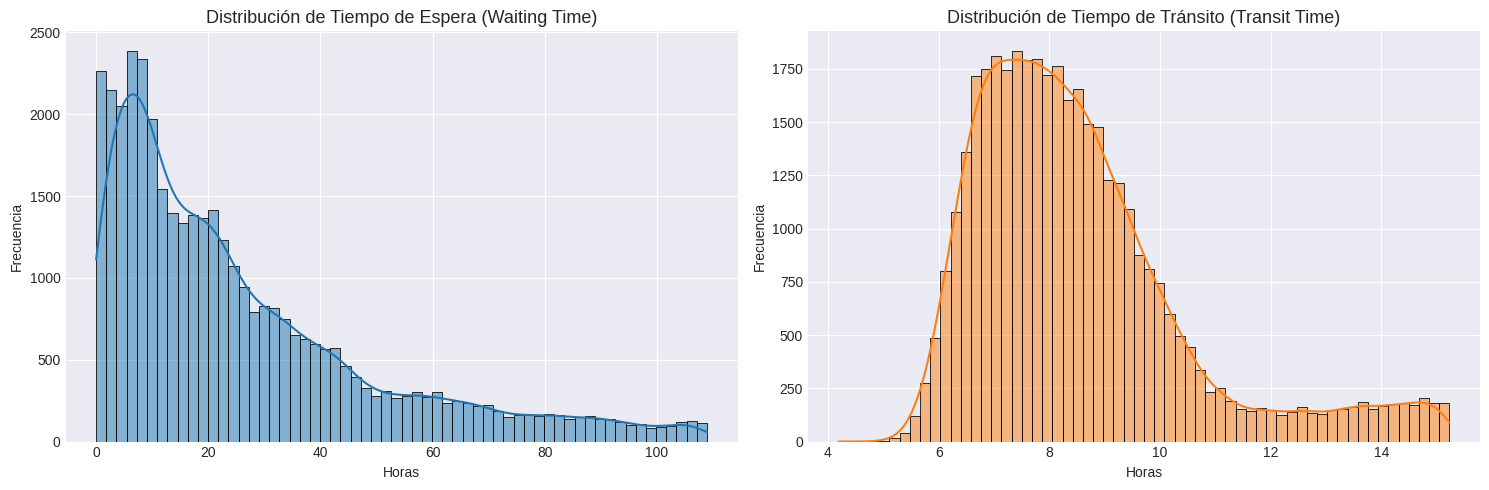

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. HISTOGRAMAS DE DISTRIBUCIÓN
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para waiting_time
sns.histplot(df['waiting_time'], bins=60, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribución de Tiempo de Espera (Waiting Time)', fontsize=13)
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Frecuencia')

# Histograma para transit_time
sns.histplot(df['transit_time'], bins=60, kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Distribución de Tiempo de Tránsito (Transit Time)', fontsize=13)
axes[1].set_xlabel('Horas')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


El tiempo de espera muestra una distribución sesgada a la derecha. Muchos barcos esperan poco, pero algunos esperan muchísimo.


Mientras que el tiempo de tránsito tiene una distribución más normal.
La mayoría de los tránsitos se concentran entre 7 y 9 horas.


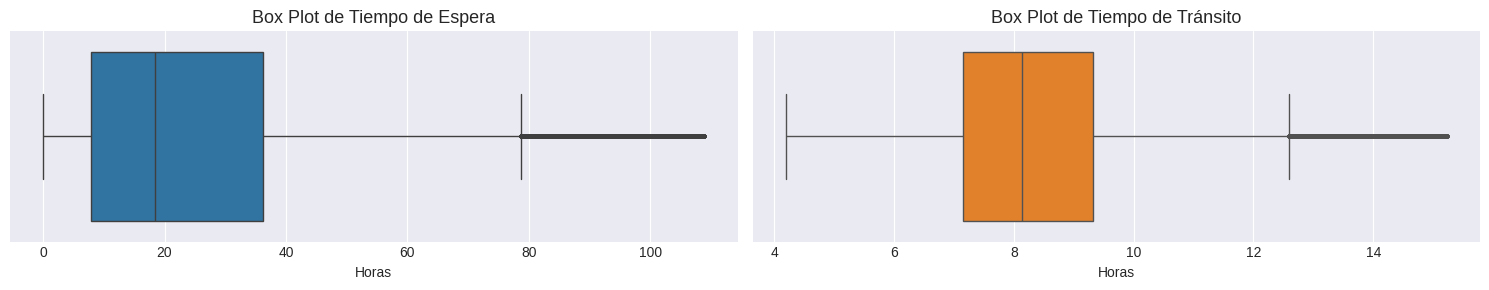

In [ ]:
# ==========================================
# 2. DIAGRAMAS DE CAJA (BOX PLOTS)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Boxplot para waiting_time
sns.boxplot(x=df['waiting_time'], ax=axes[0], color='#1f77b4', fliersize=2)
axes[0].set_title('Box Plot de Tiempo de Espera', fontsize=13)
axes[0].set_xlabel('Horas')

# Boxplot para transit_time
sns.boxplot(x=df['transit_time'], ax=axes[1], color='#ff7f0e', fliersize=2)
axes[1].set_title('Box Plot de Tiempo de Tránsito', fontsize=13)
axes[1].set_xlabel('Horas')

plt.tight_layout()
plt.show()

Tiempo de espera muestra alta dispersión y aún se ve presencia de valores extremos (hasta más de 100 horas).


Tiempo de tránsito está más concentrado, con menor variabilidad.


/tmp/ipykernel_7130/3210019588.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='waiting_time', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_7130/3210019588.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='transit_time', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_7130/3210019588.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Tipo de Tránsito', y='waiting_time', ax=axes[1, 0], palette='Pastel1')
/tmp/ipykernel_7130/3210019588.py

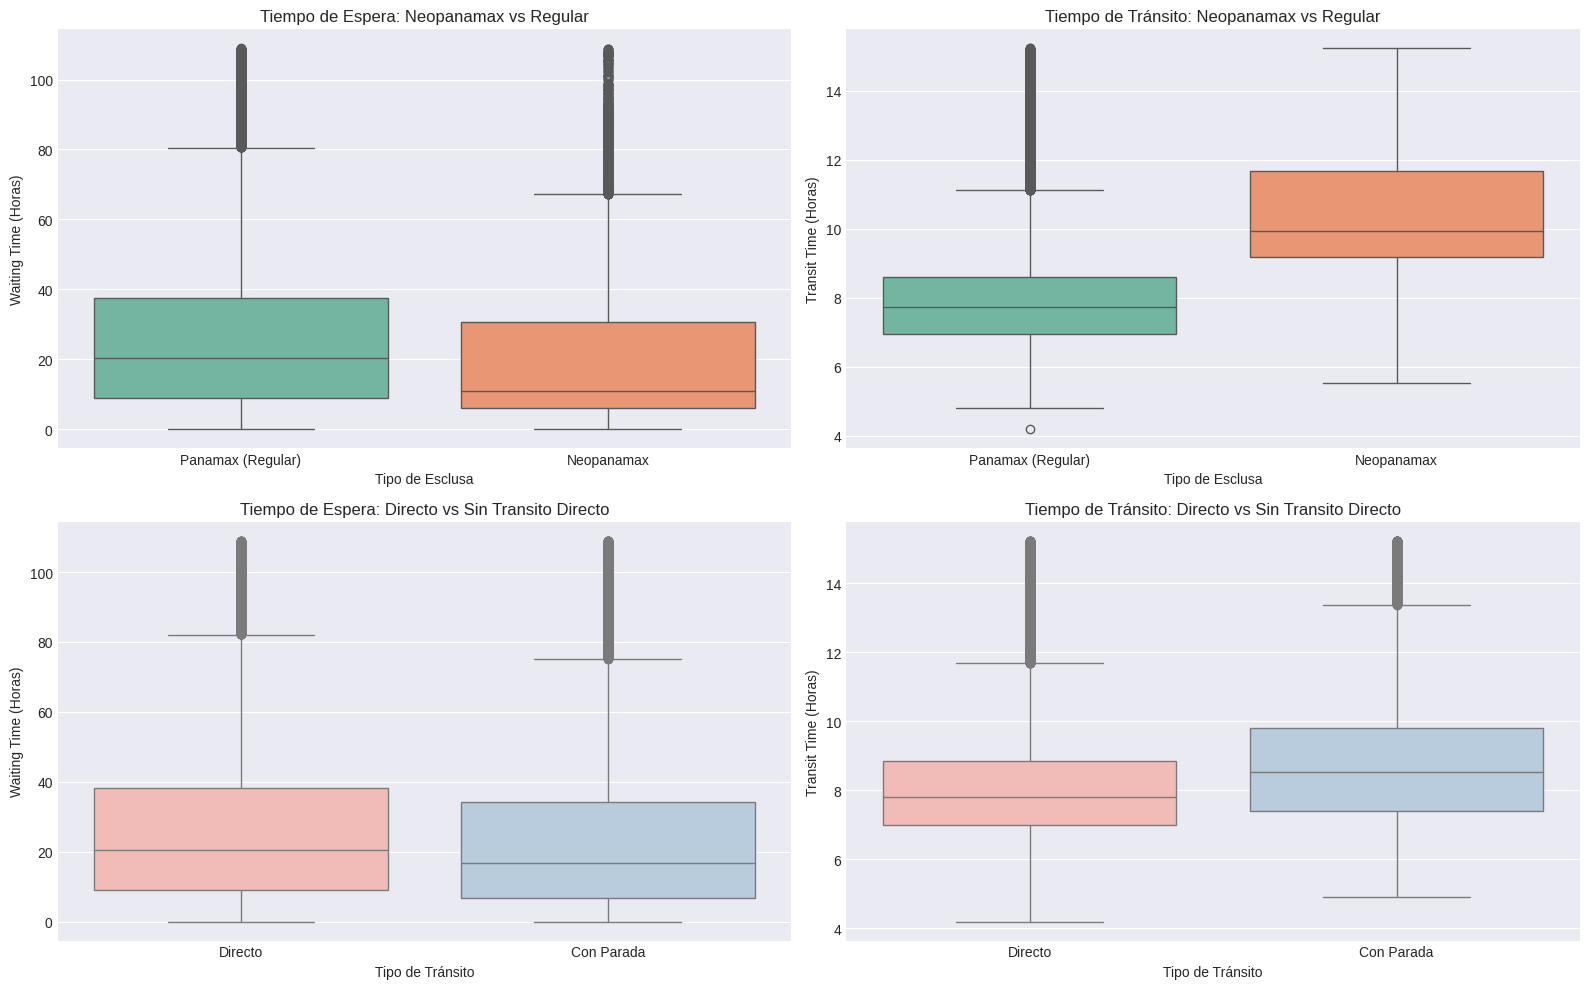

In [ ]:
# Creamos una copia para no alterar el original y ponerle etiquetas legibles a los gráficos
plot_data = df.copy()

# Mapeamos los valores binarios a texto explicativo (asumiendo 1=Sí, 0=No/Regular)
plot_data['Tipo de Esclusa'] = plot_data['neo_transit'].map({1: 'Neopanamax', 0: 'Panamax (Regular)'})
plot_data['Tipo de Tránsito'] = plot_data['direct_transit'].map({1: 'Directo', 0: 'Con Parada'})

# =========================================================
# 1. Matriz de Boxplots (Impacto individual)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fila 1: Impacto de las Esclusas (neo_transit)
sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='waiting_time', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Tiempo de Espera: Neopanamax vs Regular', fontsize=12)
axes[0, 0].set_ylabel('Waiting Time (Horas)')

sns.boxplot(data=plot_data, x='Tipo de Esclusa', y='transit_time', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Tiempo de Tránsito: Neopanamax vs Regular', fontsize=12)
axes[0, 1].set_ylabel('Transit Time (Horas)')

# Fila 2: Impacto del Tránsito Directo (direct_transit)
sns.boxplot(data=plot_data, x='Tipo de Tránsito', y='waiting_time', ax=axes[1, 0], palette='Pastel1')
axes[1, 0].set_title('Tiempo de Espera: Directo vs Sin Transito Directo', fontsize=12)
axes[1, 0].set_ylabel('Waiting Time (Horas)')

sns.boxplot(data=plot_data, x='Tipo de Tránsito', y='transit_time', ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Tiempo de Tránsito: Directo vs Sin Transito Directo', fontsize=12)
axes[1, 1].set_ylabel('Transit Time (Horas)')

plt.tight_layout()
plt.show()


Comparando los tiempos de tránsito y de espera de los buques Panamax contra los Neopanamax, notamos que los buques Neopanamax son más exigentes operativamente por lo que tardan más en transitar y, además, tienden a experimentar mayores tiempos de espera, lo que refleja mayor complejidad en su gestión dentro del Canal.


Al comparar los tiempos de espera y de tránsito de buques con tránsito directo contra los que hacen parada en los puertos, notamos que no hay una diferencia marcada entre ambos. Las medianas son similares, aunque el tránsito directo muestra un tiempo de espera ligeramente superior, y un tiempo de tránsito ligeramente inferior.





#### **Tiempo de espera y tránsito por vessel type**

<Figure size 1600x800 with 0 Axes>

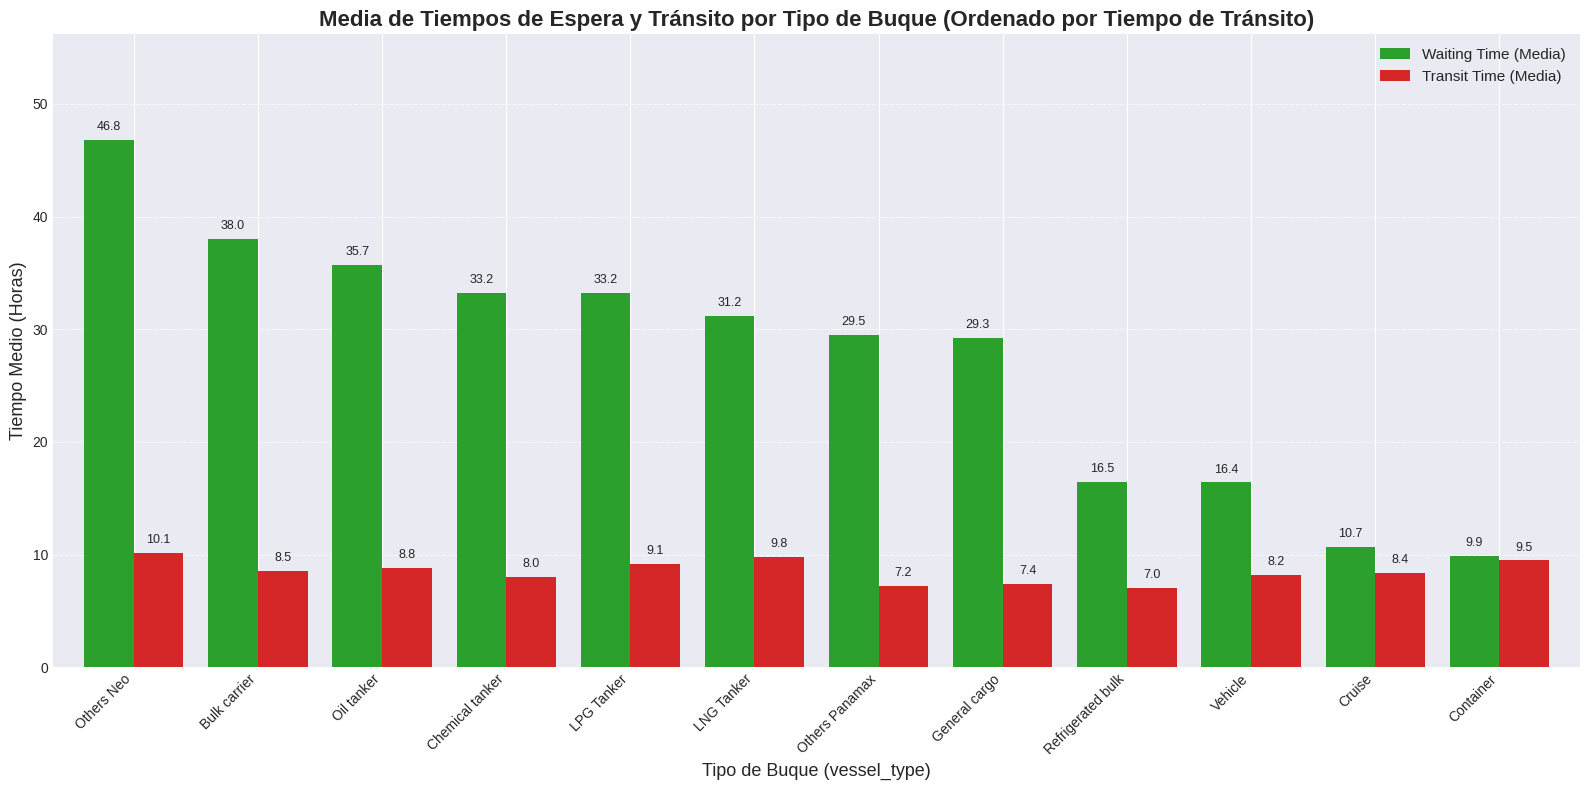

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Agrupar por 'vessel_type' y obtener la media
avg_times = df.groupby('vessel_type')[['waiting_time', 'transit_time']].mean()

# 2. Ordenar de mayor a menor según el transit_time (ya está así, aseguramos la visualización)
avg_times = avg_times.sort_values(by='waiting_time', ascending=False)

# 3. Crear el gráfico de barras con Seaborn para mejor estética
plt.figure(figsize=(16, 8))
ax = avg_times.plot(kind='bar', figsize=(16, 8), width=0.8, color=['#2ca02c', '#d62728'])

# 4. Configurar detalles estéticos
plt.title('Media de Tiempos de Espera y Tránsito por Tipo de Buque (Ordenado por Tiempo de Tránsito)', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Buque (vessel_type)', fontsize=13)
plt.ylabel('Tiempo Medio (Horas)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(['Waiting Time (Media)', 'Transit Time (Media)'], fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ==========================================
# 5. AGREGAR ETIQUETAS A LAS BARRAS
# ==========================================
for container in ax.containers:
    # fmt='%.1f' formatea a 1 decimal
    ax.bar_label(container, fmt='%.1f', label_type='edge', padding=5, fontsize=9)

# Expandir el límite superior del eje Y para que los textos no choquen con el techo
plt.ylim(0, avg_times.values.max() * 1.20) # Aumentado el 15% a 20% para mayor espacio

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()

Los tiempos de tránsito son bastante parecidos entre buques, pero el tiempo de espera sí cambia mucho.

Los cruceros, contenedores, cargas refrigeradas y vehículos esperan poco, mientras que bulk carriers, tankers y “others” esperan bastante más.

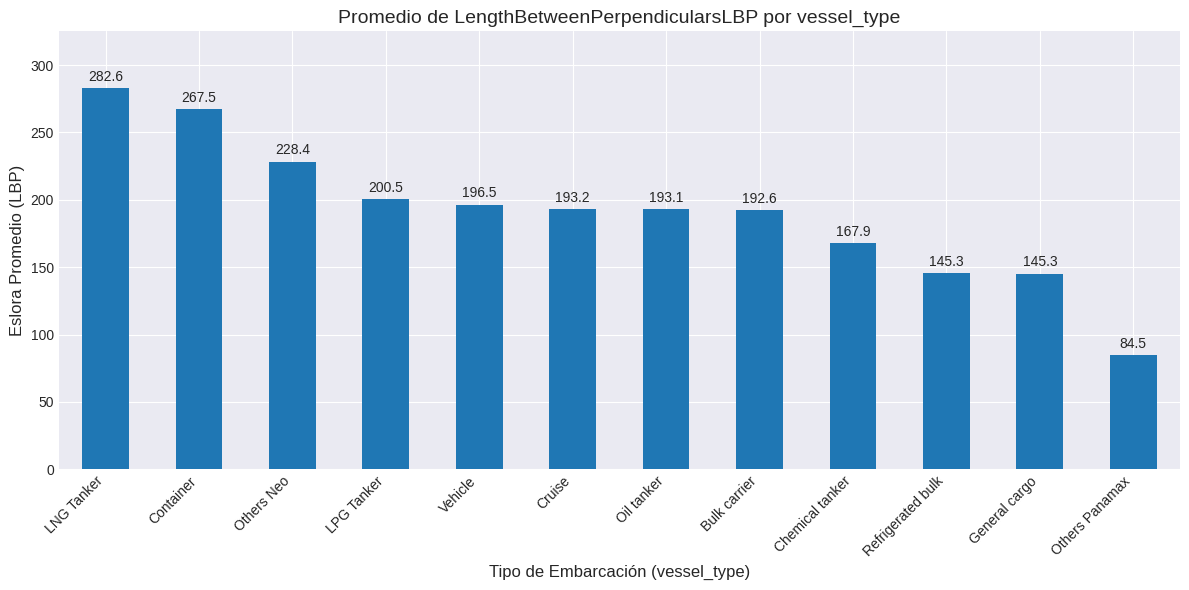

,Promedio_LBP
vessel_type,
LNG Tanker,282.645517
Container,267.527018
Others Neo,228.392692
LPG Tanker,200.497689
Vehicle,196.487252
Cruise,193.217358
Oil tanker,193.122505
Bulk carrier,192.626076
Chemical tanker,167.868210


In [ ]:
import matplotlib.pyplot as plt

# Calcular el promedio de eslora (Length) por tipo de embarcación y ordenarlo
avg_length = df.groupby('vessel_type')['LengthBetweenPerpendicularsLBP'].mean().sort_values(ascending=False)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6))
avg_length.plot(kind='bar', ax=ax, color='#1f77b4')

# Añadir las etiquetas de datos a cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', padding=3)

# Ajustar el límite 'y' para que las etiquetas no se corten
plt.ylim(0, avg_length.max() * 1.15)

# Configurar títulos y etiquetas
plt.title('Promedio de LengthBetweenPerpendicularsLBP por vessel_type', fontsize=14)
plt.xlabel('Tipo de Embarcación (vessel_type)', fontsize=12)
plt.ylabel('Eslora Promedio (LBP)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Mostrar la tabla de valores exactos
display(avg_length.to_frame(name='Promedio_LBP'))

#### **Mapa de correlación**

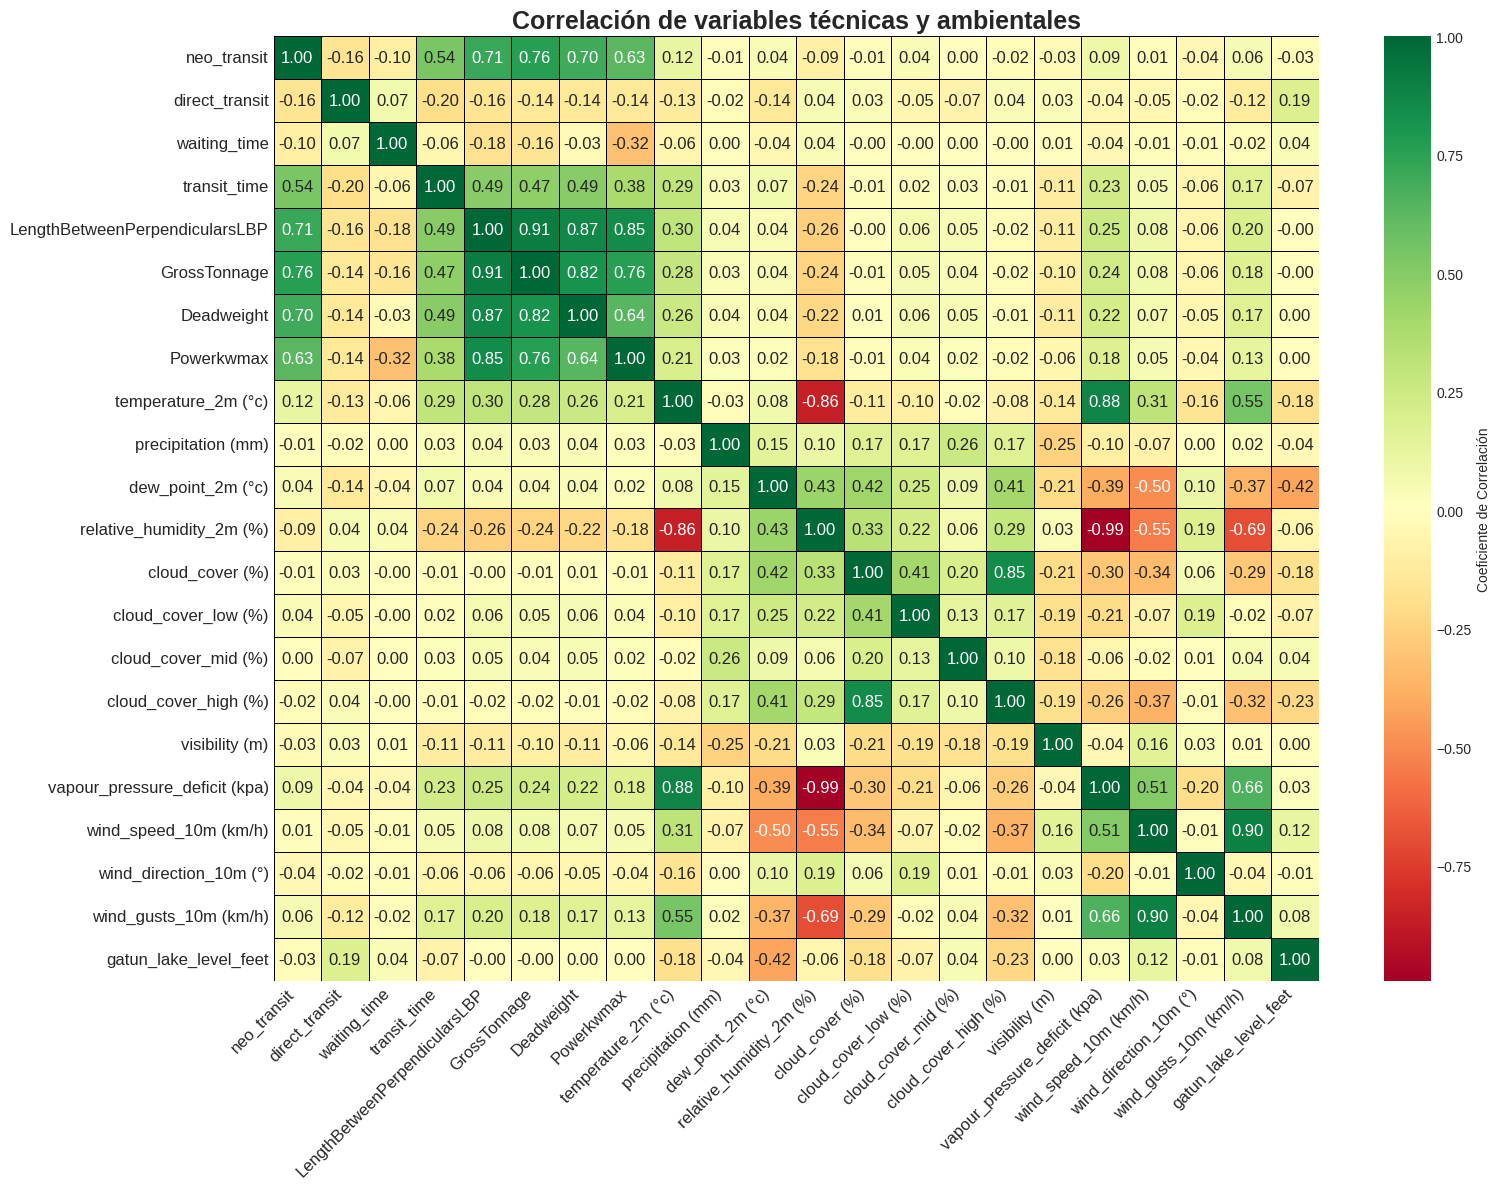

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de correlación

plt.figure(figsize=(16, 12)) # Aumentar el tamaño de la figura para más espacio
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f",
            linewidths=.5, linecolor='black',
            annot_kws={"size": 12}, # Aumentar tamaño de fuente de anotaciones
            cbar_kws={'label': 'Coeficiente de Correlación'}) # Añadir etiqueta a la barra de color
plt.title("Correlación de variables técnicas y ambientales", fontsize=18, fontweight='bold') # Aumentar tamaño y hacer el título en negrita
plt.xticks(fontsize=12, rotation=45, ha='right') # Aumentar tamaño y rotar etiquetas del eje X para evitar solapamiento
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout() # Ajustar el diseño para evitar recortes
plt.show()

* El tamaño del buque es lo que más influye en el tiempo de tránsito.

* El clima y el viento casi no afectan, y el tiempo de espera no muestra relación clara con nada.

* Las variables de tamaño (Length, GrossTonnage y Deadweight) están fuertemente relacionadas entre sí, o sea, buques más largos tienden a ser más pesados y con mayor capacidad.

* También hay relación alta entre los componentes del viento (u_wind y v_wind), lo que indica que describen el mismo fenómeno desde distintas direcciones.

#### **Tabla de correlación**

In [ ]:
import pandas as pd

# Obtener la matriz de correlación para variables numéricas
correlation_matrix = df.corr(numeric_only=True)

# Reducir los valores numéricos a 2 decimales
correlation_matrix_formatted = correlation_matrix.round(2)

# Mostrar la tabla de correlación compactada
display(correlation_matrix_formatted)

# --- Filtrar la tabla para traer variables con mayor correlación respecto a transit_time y waiting_time ---

# Definir un umbral de correlación (ej. 0.20)
correlation_threshold = 0.15

print(f"\nVariables con una correlación (en valor absoluto) de al menos {correlation_threshold} con 'transit_time':")
# Filtrar correlaciones para 'transit_time'
correlations_transit_time = correlation_matrix['transit_time']
filtered_transit_time_corr = correlations_transit_time[
    (abs(correlations_transit_time) >= correlation_threshold) & (correlations_transit_time.index != 'transit_time')
].sort_values(ascending=False)

if not filtered_transit_time_corr.empty:
    display(filtered_transit_time_corr.to_frame(name='Correlación con Transit Time').round(2))
    filtered_transit_time_corr.to_csv('correlation_with_transit_time.csv', header=True)
    print("Tabla de correlación con 'transit_time' exportada a 'correlation_with_transit_time.csv'")
else:
    print(f"No se encontraron variables con una correlación igual o superior a {correlation_threshold} con 'transit_time'.")

print(f"\nVariables con una correlación (en valor absoluto) de al menos {correlation_threshold} con 'waiting_time':")
# Filtrar correlaciones para 'waiting_time'
correlations_waiting_time = correlation_matrix['waiting_time']
filtered_waiting_time_corr = correlations_waiting_time[
    (abs(correlations_waiting_time) >= correlation_threshold) & (correlations_waiting_time.index != 'waiting_time')
].sort_values(ascending=False)

if not filtered_waiting_time_corr.empty:
    display(filtered_waiting_time_corr.to_frame(name='Correlación con Waiting Time').round(2))
    filtered_waiting_time_corr.to_csv('correlation_with_waiting_time.csv', header=True)
    print("Tabla de correlación con 'waiting_time' exportada a 'correlation_with_waiting_time.csv'")
else:
    print(f"No se encontraron variables con una correlación igual o superior a {correlation_threshold} con 'waiting_time'.")

,neo_transit,direct_transit,waiting_time,transit_time,LengthBetweenPerpendicularsLBP,GrossTonnage,Deadweight,Powerkwmax,temperature_2m (°c),precipitation (mm),...,cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),visibility (m),vapour_pressure_deficit (kpa),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),gatun_lake_level_feet
neo_transit,1.00,-0.16,-0.10,0.54,0.71,0.76,0.70,0.63,0.12,-0.01,...,-0.01,0.04,0.00,-0.02,-0.03,0.09,0.01,-0.04,0.06,-0.03
direct_transit,-0.16,1.00,0.07,-0.20,-0.16,-0.14,-0.14,-0.14,-0.13,-0.02,...,0.03,-0.05,-0.07,0.04,0.03,-0.04,-0.05,-0.02,-0.12,0.19
waiting_time,-0.10,0.07,1.00,-0.06,-0.18,-0.16,-0.03,-0.32,-0.06,0.00,...,-0.00,-0.00,0.00,-0.00,0.01,-0.04,-0.01,-0.01,-0.02,0.04
transit_time,0.54,-0.20,-0.06,1.00,0.49,0.47,0.49,0.38,0.29,0.03,...,-0.01,0.02,0.03,-0.01,-0.11,0.23,0.05,-0.06,0.17,-0.07
LengthBetweenPerpendicularsLBP,0.71,-0.16,-0.18,0.49,1.00,0.91,0.87,0.85,0.30,0.04,...,-0.00,0.06,0.05,-0.02,-0.11,0.25,0.08,-0.06,0.20,-0.00
GrossTonnage,0.76,-0.14,-0.16,0.47,0.91,1.00,0.82,0.76,0.28,0.03,...,-0.01,0.05,0.04,-0.02,-0.10,0.24,0.08,-0.06,0.18,-0.00
Deadweight,0.70,-0.14,-0.03,0.49,0.87,0.82,1.00,0.64,0.26,0.04,...,0.01,0.06,0.05,-0.01,-0.11,0.22,0.07,-0.05,0.17,0.00
Powerkwmax,0.63,-0.14,-0.32,0.38,0.85,0.76,0.64,1.00,0.21,0.03,...,-0.01,0.04,0.02,-0.02,-0.06,0.18,0.05,-0.04,0.13,0.00
temperature_2m (°c),0.12,-0.13,-0.06,0.29,0.30,0.28,0.26,0.21,1.00,-0.03,...,-0.11,-0.10,-0.02,-0.08,-0.14,0.88,0.31,-0.16,0.55,-0.18
precipitation (mm),-0.01,-0.02,0.00,0.03,0.04,0.03,0.04,0.03,-0.03,1.00,...,0.17,0.17,0.26,0.17,-0.25,-0.10,-0.07,0.00,0.02,-0.04



Variables con una correlación (en valor absoluto) de al menos 0.15 con 'transit_time':


,Correlación con Transit Time
neo_transit,0.54
Deadweight,0.49
LengthBetweenPerpendicularsLBP,0.49
GrossTonnage,0.47
Powerkwmax,0.38
temperature_2m (°c),0.29
vapour_pressure_deficit (kpa),0.23
wind_gusts_10m (km/h),0.17
direct_transit,-0.20
relative_humidity_2m (%),-0.24


Tabla de correlación con 'transit_time' exportada a 'correlation_with_transit_time.csv'

Variables con una correlación (en valor absoluto) de al menos 0.15 con 'waiting_time':


,Correlación con Waiting Time
GrossTonnage,-0.16
LengthBetweenPerpendicularsLBP,-0.18
Powerkwmax,-0.32


Tabla de correlación con 'waiting_time' exportada a 'correlation_with_waiting_time.csv'


In [ ]:
correlation_matrix.to_csv('correlation_table.csv', index=True)
print("Tabla de correlación exportada a 'correlation_table.csv'")

Tabla de correlación exportada a 'correlation_table.csv'


#### **Análisis de estacionalidad tiempo de tránsito y tiempo de espera**

Estacionalidad para el tiempo de tránsito

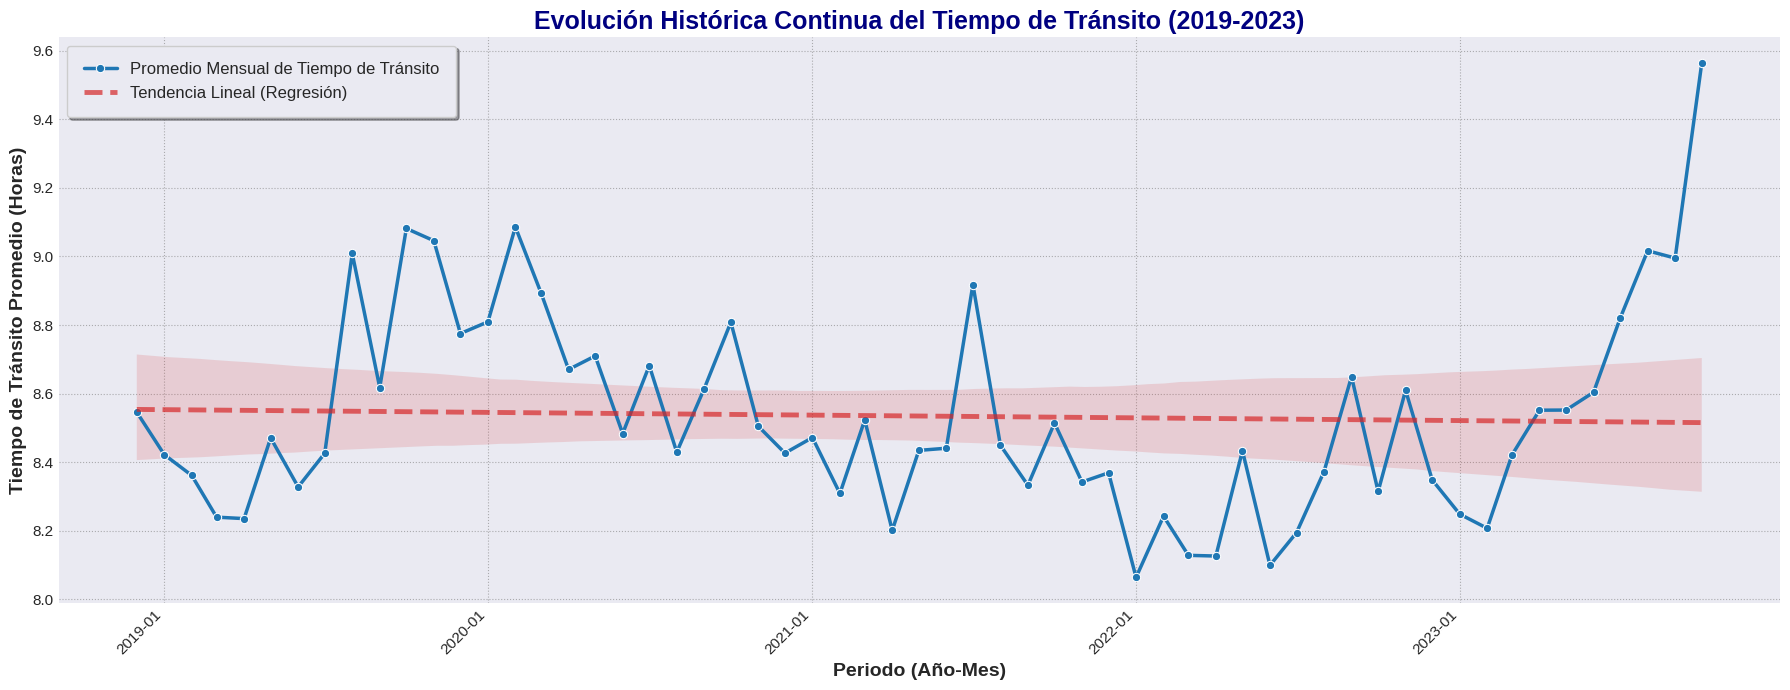

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Aseguramos que el periodo sea datetime y ordenamos
df_trend = df.groupby(df['time_anchoring_in'].dt.to_period('M'))['transit_time'].mean().reset_index()
df_trend['periodo'] = df_trend['time_anchoring_in'].dt.to_timestamp()

# --- MEJORAS EN LA VISUALIZACIÓN ---

# Establecer un estilo profesional para el gráfico
plt.style.use('seaborn-v0_8-darkgrid') # Un estilo limpio y moderno

plt.figure(figsize=(18, 7))

# 2. Graficamos los datos reales con un color más vibrante y markers estilizados
sns.lineplot(data=df_trend, x='periodo', y='transit_time',
             marker='o', markersize=6, linestyle='-',
             color='#1f77b4', linewidth=2.5, label='Promedio Mensual de Tiempo de Tránsito')

# 3. TRUCO: Convertimos las fechas a números que regplot entienda en la misma escala
x_numeric = mdates.date2num(df_trend['periodo'])

sns.regplot(x=x_numeric,
            y=df_trend['transit_time'].values,
            scatter=False, # No queremos los puntos individuales de la regresión
            color='#d62728', # Un rojo distintivo para la tendencia
            line_kws={'linestyle': '--', 'linewidth': 3.5, 'alpha': 0.7},
            label='Tendencia Lineal (Regresión)')

# 4. Formateo del eje X para que no se rompa
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator()) # Mostrar etiquetas por año
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator()) # Marcadores menores por mes

# Configuración de títulos y etiquetas
plt.title('Evolución Histórica Continua del Tiempo de Tránsito (2019-2023)', fontsize=18, fontweight='bold', color='navy')
plt.xlabel('Periodo (Año-Mes)', fontsize=14, fontweight='semibold')
plt.ylabel('Tiempo de Tránsito Promedio (Horas)', fontsize=14, fontweight='semibold')

# Mejorar la leyenda
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, borderpad=1)

# Mejorar la cuadrícula
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Rotar etiquetas del eje X para evitar solapamiento y hacerlas más legibles
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Ajustar el diseño para asegurar que todo encaje bien
plt.tight_layout()
plt.show()

El tiempo de tránsito se ha mantenido bastante estable a lo largo de los años, con pequeñas fluctuaciones mes a mes. La tendencia general es ligeramente a la baja.

Estacionalidad para el tiempo de espera

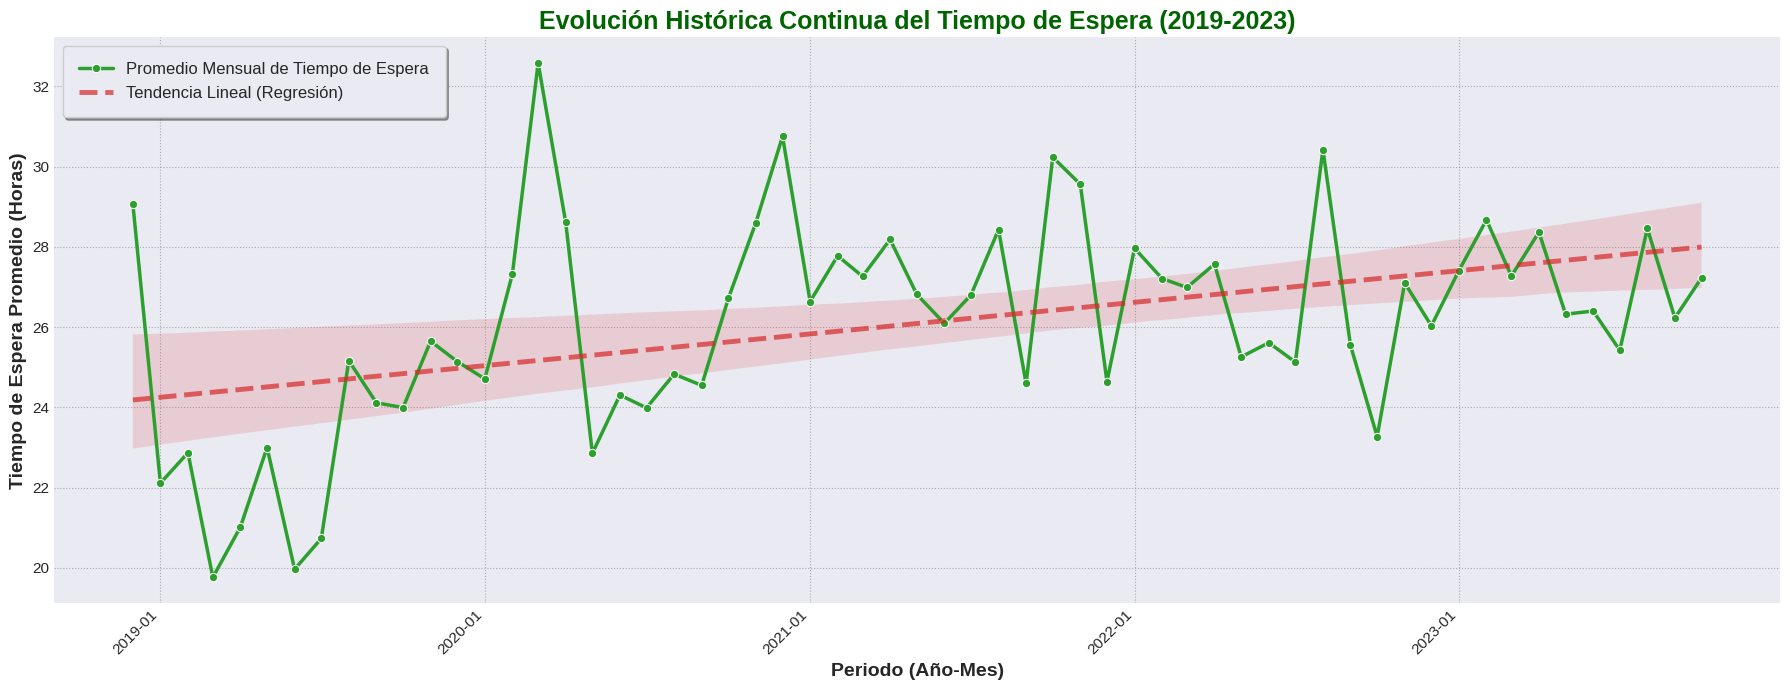

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Aseguramos que el periodo sea datetime y ordenamos
df_trend = df.groupby(df['time_anchoring_in'].dt.to_period('M'))['waiting_time'].mean().reset_index()
df_trend['periodo'] = df_trend['time_anchoring_in'].dt.to_timestamp()

# --- MEJORAS EN LA VISUALIZACIÓN ---

# Establecer un estilo profesional para el gráfico
plt.style.use('seaborn-v0_8-darkgrid') # Un estilo limpio y moderno

plt.figure(figsize=(18, 7))

# 2. Graficamos los datos reales con un color más vibrante y markers estilizados
sns.lineplot(data=df_trend, x='periodo', y='waiting_time',
             marker='o', markersize=6, linestyle='-',
             color='#2ca02c', linewidth=2.5, label='Promedio Mensual de Tiempo de Espera')

# 3. TRUCO: Convertimos las fechas a números que regplot entienda en la misma escala
x_numeric = mdates.date2num(df_trend['periodo'])

sns.regplot(x=x_numeric,
            y=df_trend['waiting_time'].values,
            scatter=False, # No queremos los puntos individuales de la regresión
            color='#d62728', # Un rojo distintivo para la tendencia
            line_kws={'linestyle': '--', 'linewidth': 3.5, 'alpha': 0.7},
            label='Tendencia Lineal (Regresión)')

# 4. Formateo del eje X para que no se rompa
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator()) # Mostrar etiquetas por año
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator()) # Marcadores menores por mes

# Configuración de títulos y etiquetas
plt.title('Evolución Histórica Continua del Tiempo de Espera (2019-2023)', fontsize=18, fontweight='bold', color='darkgreen')
plt.xlabel('Periodo (Año-Mes)', fontsize=14, fontweight='semibold')
plt.ylabel('Tiempo de Espera Promedio (Horas)', fontsize=14, fontweight='semibold')

# Mejorar la leyenda
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, borderpad=1)

# Mejorar la cuadrícula
plt.grid(True, linestyle=':', alpha=0.6, color='gray')

# Rotar etiquetas del eje X para evitar solapamiento y hacerlas más legibles
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Ajustar el diseño para asegurar que todo encaje bien
plt.tight_layout()
plt.show()

El tiempo de espera muestra una tendencia al alza con los años.
Aunque hay bastante variabilidad mes a mes, en general cada vez se espera más, lo que sugiere mayor congestión o presión sobre la capacidad del canal.

#### **Cantidad de barcos que transitan de forma anual-mensual-diaria**



In [ ]:
import pandas as pd

# Aseguramos que las variables de tiempo existan
df['anio'] = df['time'].dt.year
df['mes'] = df['time'].dt.month
df['fecha'] = df['time'].dt.date

# 1. Agrupación por Año
stats_anio = df.groupby('anio').agg(
    cantidad_barcos=('imo', 'count'),
    promedio_transito=('transit_time', 'mean'),
    promedio_espera=('waiting_time', 'mean')
).reset_index()

# 2. Agrupación por Mes (Estacionalidad histórica)
stats_mes = df.groupby('mes').agg(
    cantidad_barcos_total=('imo', 'count'),
    promedio_transito=('transit_time', 'mean'),
    promedio_espera=('waiting_time', 'mean')
).reset_index()

# 3. Agrupación Diaria (Para ver la carga operativa real)
stats_dia = df.groupby('fecha').agg(
    barcos_por_dia=('imo', 'count'),
    promedio_transito=('transit_time', 'mean'),
    promedio_espera=('waiting_time', 'mean')
).reset_index()

# Calcular la media de barcos por día (general)
media_barcos_por_dia_general = stats_dia['barcos_por_dia'].mean()
print(f"Media de barcos por día (general): {media_barcos_por_dia_general:.2f}")

# Calculate average daily ships per year
stats_dia['anio'] = pd.to_datetime(stats_dia['fecha']).dt.year
avg_daily_ships_per_year = stats_dia.groupby('anio')['barcos_por_dia'].mean().reset_index()
avg_daily_ships_per_year.rename(columns={'barcos_por_dia': 'Media Barcos por Día'}, inplace=True)

# Calculate average monthly ships per year
monthly_ships_per_year = df.groupby(['anio', 'mes'])['imo'].count().reset_index()
avg_monthly_ships_per_year = monthly_ships_per_year.groupby('anio')['imo'].mean().reset_index()
avg_monthly_ships_per_year.rename(columns={'imo': 'Media Barcos por Mes'}, inplace=True)

# Resumen ejecutivo por año (sin incertidumbres ni % Prioritarios)
resumen_ejecutivo = df.groupby('anio').agg({
    'imo': 'count',
    'transit_time': 'mean',
    'waiting_time': 'mean'
}).reset_index()

# Merge the new metrics
resumen_ejecutivo = pd.merge(resumen_ejecutivo, avg_daily_ships_per_year, on='anio', how='left')
resumen_ejecutivo = pd.merge(resumen_ejecutivo, avg_monthly_ships_per_year, on='anio', how='left')

# Renombrar columnas para claridad
resumen_ejecutivo.columns = [
    'Año', 'Total Barcos', 'Tránsito Medio (h)',
    'Espera Media (h)', 'Media Barcos por Día', 'Media Barcos por Mes'
]

resumen_ejecutivo.set_index('Año', inplace=True)


Media de barcos por día (general): 21.73


In [ ]:
resumen_ejecutivo_reordenado = resumen_ejecutivo[[
    'Total Barcos',
    'Media Barcos por Mes',
    'Media Barcos por Día',
    'Espera Media (h)',
    'Tránsito Medio (h)'
]].copy()

resumen_ejecutivo_reordenado.rename(columns={
    'Media Barcos por Mes': 'Media Mensual',
    'Media Barcos por Día': 'Media por Día',
    'Espera Media (h)': 'Tiempo Medio Espera',
    'Tránsito Medio (h)': 'Tiempo Transito Medio'
}, inplace=True)

display(resumen_ejecutivo_reordenado)

,Total Barcos,Media Mensual,Media por Día,Tiempo Medio Espera,Tiempo Transito Medio
Año,,,,,
2019,8817,734.750000,24.156164,22.730279,8.587147
2020,8204,683.666667,22.415301,26.670785,8.675388
2021,8037,669.750000,22.263158,27.377700,8.434312
2022,7069,589.083333,19.420330,26.381266,8.298947
2023,6094,609.400000,20.112211,27.363117,8.664520


La cantidad de barcos viene bajando cada año, sobre todo desde 2019 hasta 2023.

Aún con menos tráfico, el tiempo de espera aumenta, pasando de 23.8 a 29.4 horas. Hay más demora dentro del sistema.

El tiempo de tránsito se mantiene bastante estable, incluso baja en 2022 y luego sube un poco en 2023.

## **MODELO PREDICTIVO**

In [ ]:
import pandas as pd
import numpy as np

# Asegurarnos de que las columnas son formato fecha (por si acaso)
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])

# 1. ORDENAMIENTO CRONOLÓGICO (Vital para el rolling window)
df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

# 2. INGENIERÍA TEMPORAL (Mes y Día de la semana)
df['mes'] = df['time_at_entrance'].dt.month
df['dia_semana'] = df['time_at_entrance'].dt.dayofweek # 0=Lunes, 6=Domingo (Ayuda a ver patrones de fin de semana)

# 4. INGENIERÍA DE VARIABLES CÍCLICAS (Hora del día)
df['hora'] = df['time_at_entrance'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# 5. NUEVA SELECCIÓN DE CARACTERÍSTICAS (X)
# Observa que hemos añadido 'mes', 'dia_semana', 'llegadas_ultimas_24h' y 'llegadas_ultimas_48h'
features = [
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]


X = df[features].copy()
y = df[['transit_time', 'waiting_time']]

# 6. ONE-HOT ENCODING DE CATEGORÍAS
columnas_categoricas = ['vessel_type', 'transit_bound', 'MainEngineType', 'ShiptypeLevel5']
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

# 7. SPLIT CRONOLÓGICO (80% Entrenamiento / 20% Prueba)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print(f"--- Dataset Final Preparado ---")
print(f"Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h")
print(f"Dimensiones de X_train: {X_train.shape}")

--- Dataset Final Preparado ---
Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h
Dimensiones de X_train: (30576, 104)


#### **Modelo de ML usando Random Forest**

#####Ingeniería de Features

Evaluando importancia de variables para 'transit_time'...
Evaluando importancia de variables para 'waiting_time'...


/tmp/ipykernel_7130/1721581285.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
/tmp/ipykernel_7130/1721581285.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')


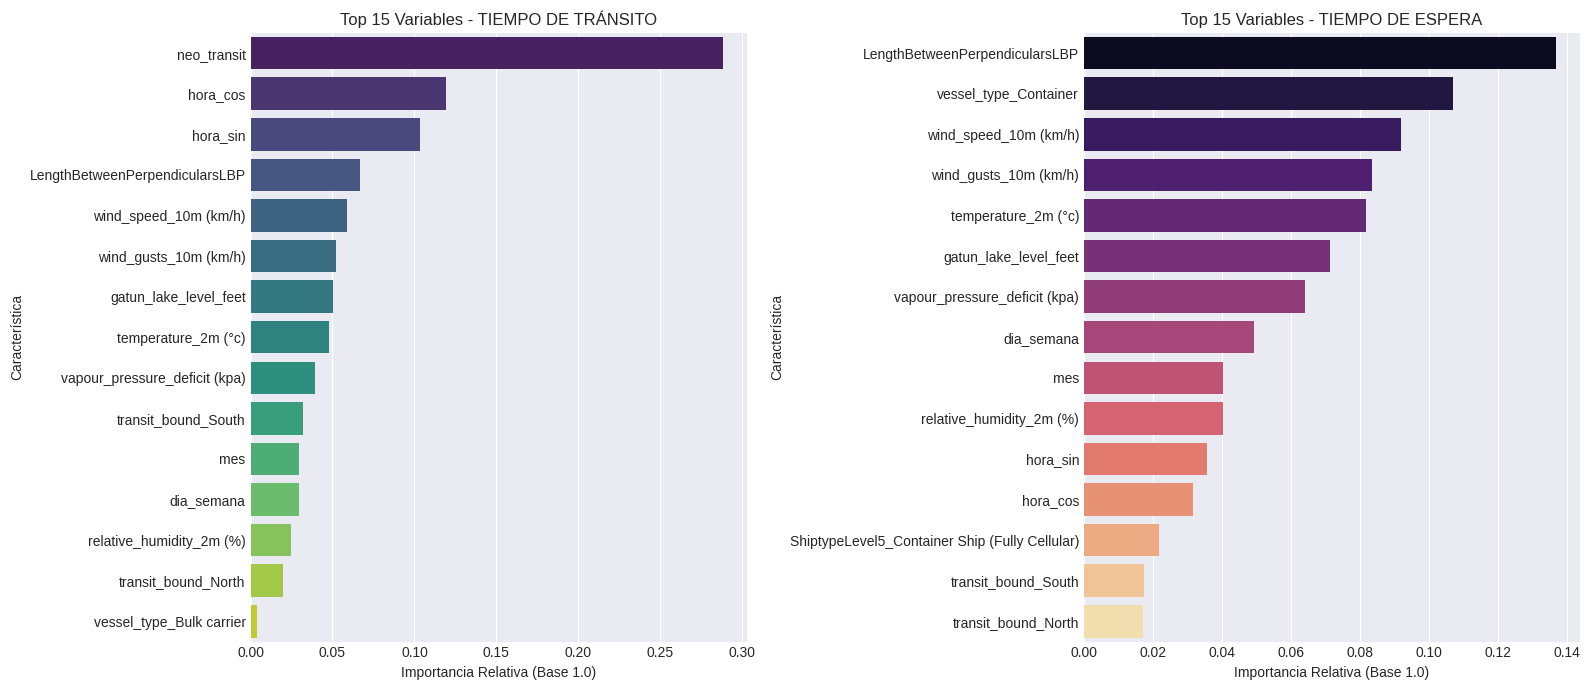


--- TOP 5 VARIABLES PARA TRÁNSITO ---
                Característica  Importancia
                   neo_transit     0.288185
                      hora_cos     0.119095
                      hora_sin     0.103085
LengthBetweenPerpendicularsLBP     0.066921
         wind_speed_10m (km/h)     0.058685

--- TOP 5 VARIABLES PARA ESPERA ---
                Característica  Importancia
LengthBetweenPerpendicularsLBP     0.137049
         vessel_type_Container     0.107180
         wind_speed_10m (km/h)     0.091908
         wind_gusts_10m (km/h)     0.083618
           temperature_2m (°c)     0.081921

Los resultados de importancia de características han sido exportados a:
- 'feature_importance_transit.csv'
- 'feature_importance_waiting.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ---

print("Evaluando importancia de variables para 'transit_time'...")
# Usamos un Random Forest rápido para extraer las importancias
rf_transit = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_transit.fit(X_train, y_train['transit_time'])

# Guardamos las importancias en un DataFrame y lo ordenamos
importancias_transit = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': rf_transit.feature_importances_
}).sort_values(by='Importancia', ascending=False)


print("Evaluando importancia de variables para 'waiting_time'...")
rf_waiting = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_waiting.fit(X_train, y_train['waiting_time'])

importancias_waiting = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': rf_waiting.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# --- VISUALIZACIÓN ---
# Crear un gráfico de barras con el "Top 15" de variables para cada variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico para Tránsito
sns.barplot(data=importancias_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Variables - TIEMPO DE TRÁNSITO')
axes[0].set_xlabel('Importancia Relativa (Base 1.0)')

# Gráfico para Espera
sns.barplot(data=importancias_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Variables - TIEMPO DE ESPERA')
axes[1].set_xlabel('Importancia Relativa (Base 1.0)')

plt.tight_layout()
plt.show()

# Imprimir el resumen en texto
print("\n--- TOP 5 VARIABLES PARA TRÁNSITO ---")
print(importancias_transit.head(5).to_string(index=False))

print("\n--- TOP 5 VARIABLES PARA ESPERA ---")
print(importancias_waiting.head(5).to_string(index=False))

# --- EXPORTAR A CSV ---
importancias_transit.to_csv('feature_importance_transit_randomForest.csv', index=False)
importancias_waiting.to_csv('feature_importance_waiting_randomForest.csv', index=False)

print("\nLos resultados de importancia de características han sido exportados a:")
print("- 'feature_importance_transit.csv'")
print("- 'feature_importance_waiting.csv'")

##### Entrenamiento del modelo - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. Instanciamos el modelo base (Random Forest)
# Usamos parámetros equilibrados para evitar el sobreajuste (overfitting)
rf_base = RandomForestRegressor(
    n_estimators=1000,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

# 2. Envolvemos en MultiOutputRegressor
# Esto entrenará internamente un Random Forest para Tránsito y otro para Espera
model_rf = MultiOutputRegressor(rf_base)

# 3. ENTRENAMIENTO
print("Entrenando... (esto puede tardar unos minutos)")
model_rf.fit(X_train, y_train)

# 4. PREDICCIÓN
y_pred = model_rf.predict(X_test)

# Convertimos a DataFrame para facilitar la comparación
y_pred_rf = pd.DataFrame(y_pred, columns=['pred_transit', 'pred_waiting'], index=y_test.index)

Entrenando... (esto puede tardar unos minutos)


##### Resultados del modelo

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# Cálculo de errores
mae_transit = mean_absolute_error(y_test['transit_time'], y_pred_rf['pred_transit'])
mae_waiting = mean_absolute_error(y_test['waiting_time'], y_pred_rf['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y_test['transit_time'], y_pred_rf['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y_test['waiting_time'], y_pred_rf['pred_waiting']))

r2_transit = r2_score(y_test['transit_time'], y_pred_rf['pred_transit'])
r2_waiting = r2_score(y_test['waiting_time'], y_pred_rf['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y_test['transit_time'], y_pred_rf['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y_test['waiting_time'], y_pred_rf['pred_waiting'])

print(f"\n--- RESULTADOS ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# Comparativa rápida: Real vs Predicho
comparativa = pd.concat([y_test.head(10), y_pred_rf.head(10)], axis=1)
print("\nPrimeras 10 predicciones vs Realidad:")
print(comparativa)


--- RESULTADOS ---
Error Medio Absoluto en Tránsito (MAE): 0.97 horas (58 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.42 horas (85 minutos)
R2 en Tránsito: 0.49
MAPE en Tránsito: 10.65%

Error Medio Absoluto en Espera (MAE): 14.90 horas (894 minutos)
Error Cuadrático Medio en Espera (RMSE): 21.38 horas (1283 minutos)
R2 en Espera: 0.25
MAPE en Espera: 146.21%

Primeras 10 predicciones vs Realidad:
       transit_time  waiting_time  pred_transit  pred_waiting
30576      7.791944     22.166667      8.577577     41.843182
30577      8.731667      2.000000      8.407028      7.220691
30578      9.424167     22.833333      8.418048     29.755719
30579      9.159444     70.500000      8.378194     41.886404
30580      8.600833     24.500000      8.388158     29.826892
30581      8.047222     15.333333      8.542203     32.947391
30582      8.000278     18.166667      7.274487     20.427161
30583      7.869722      7.333333      7.274487     20.427161
30584      8.166667      1.500

##### Predicciones del modelo y resultados para todo el conjunto de datos

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# 1. HACER PREDICCIONES SOBRE TODO EL DATASET (X)
# Cambia 'model' por el nombre real de la variable de tu model entrenado
predicciones_totales = model_rf.predict(X)
y_pred_df_all_rf = pd.DataFrame(predicciones_totales, columns=['pred_transit', 'pred_waiting'])

# 2. CALCULAR ERRORES GLOBALES (Toda la base de datos)
mae_transit = mean_absolute_error(y['transit_time'], y_pred_df_all_rf['pred_transit'])
mae_waiting = mean_absolute_error(y['waiting_time'], y_pred_df_all_rf['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y['transit_time'], y_pred_df_all_rf['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y['waiting_time'], y_pred_df_all_rf['pred_waiting']))

r2_transit = r2_score(y['transit_time'], y_pred_df_all_rf['pred_transit'])
r2_waiting = r2_score(y['waiting_time'], y_pred_df_all_rf['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y['transit_time'], y_pred_df_all_rf['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y['waiting_time'], y_pred_df_all_rf['pred_waiting'])

print(f"\n--- RESULTADOS GLOBALES (TODO EL DATASET) ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# 3. EXTRAER CONTEXTO Y UNIR TODO
columnas_contexto = ['imo', 'time_at_entrance',
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]

df_contexto = df[columnas_contexto].reset_index(drop=True)
y_real = y.reset_index(drop=True)
y_pred = y_pred_df_all_rf.reset_index(drop=True)

# Unimos las 3 partes: Contexto + Valores Reales + Predicciones completas
comparativa = pd.concat([df_contexto, y_real, y_pred], axis=1)

print("\nMuestra de las predicciones vs Realidad (con contexto):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comparativa.head(10)) # Muestra los primeros 10 para no saturar la pantalla
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# OPCIONAL: Exportar el conjunto de datos completo a CSV para analizarlo
comparativa.to_csv('predicciones_completas_historico_randomforest.csv', index=False)


--- RESULTADOS GLOBALES (TODO EL DATASET) ---
Error Medio Absoluto en Tránsito (MAE): 0.90 horas (54 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.31 horas (79 minutos)
R2 en Tránsito: 0.55
MAPE en Tránsito: 10.11%

Error Medio Absoluto en Espera (MAE): 14.83 horas (890 minutos)
Error Cuadrático Medio en Espera (RMSE): 20.73 horas (1244 minutos)
R2 en Espera: 0.27
MAPE en Espera: 835.63%

Muestra de las predicciones vs Realidad (con contexto):
       imo    time_at_entrance      vessel_type  neo_transit transit_bound  LengthBetweenPerpendicularsLBP MainEngineType  mes  dia_semana  hora_sin      hora_cos                   ShiptypeLevel5  gatun_lake_level_feet  temperature_2m (°c)  relative_humidity_2m (%)  vapour_pressure_deficit (kpa)  wind_gusts_10m (km/h)  wind_speed_10m (km/h)  transit_time  waiting_time  pred_transit  pred_waiting
0  9717292 2019-01-01 00:29:36  Chemical tanker            0         North                          176.00            Oil    1           1  0.00

#### **Modelo de ML usando XGBRegressor**

In [ ]:
  import pandas as pd
  import numpy as np

  # Asegurarnos de que las columnas son formato fecha (por si acaso)
  df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])

  # 1. ORDENAMIENTO CRONOLÓGICO (Vital para el rolling window)
  df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

  # 2. INGENIERÍA TEMPORAL (Mes y Día de la semana)
  df['mes'] = df['time_at_entrance'].dt.month
  df['dia_semana'] = df['time_at_entrance'].dt.dayofweek # 0=Lunes, 6=Domingo (Ayuda a ver patrones de fin de semana)

  # 4. INGENIERÍA DE VARIABLES CÍCLICAS (Hora del día)
  df['hora'] = df['time_at_entrance'].dt.hour
  df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
  df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

  # 5. NUEVA SELECCIÓN DE CARACTERÍSTICAS (X)
  # Observa que hemos añadido 'mes', 'dia_semana', 'llegadas_ultimas_24h' y 'llegadas_ultimas_48h'
features = [
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]



  X = df[features].copy()
  y = df[['transit_time', 'waiting_time']]

  # 6. ONE-HOT ENCODING DE CATEGORÍAS
  columnas_categoricas = ['vessel_type', 'transit_bound', 'MainEngineType', 'ShiptypeLevel5']
  X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

  # 7. SPLIT CRONOLÓGICO (80% Entrenamiento / 20% Prueba)
  split_idx = int(len(X) * 0.8)

  X_train = X.iloc[:split_idx].copy()
  X_test = X.iloc[split_idx:].copy()
  y_train = y.iloc[:split_idx].copy()
  y_test = y.iloc[split_idx:].copy()

  print(f"--- Dataset Final Preparado ---")
  print(f"Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h")
  print(f"Dimensiones de X_train: {X_train.shape}")

--- Dataset Final Preparado ---
Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h
Dimensiones de X_train: (30576, 104)


##### **Ingenería de Features**

Evaluando importancia de variables para 'transit_time'...
Evaluando importancia de variables para 'waiting_time'...


/tmp/ipykernel_7130/3846330394.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
/tmp/ipykernel_7130/3846330394.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')


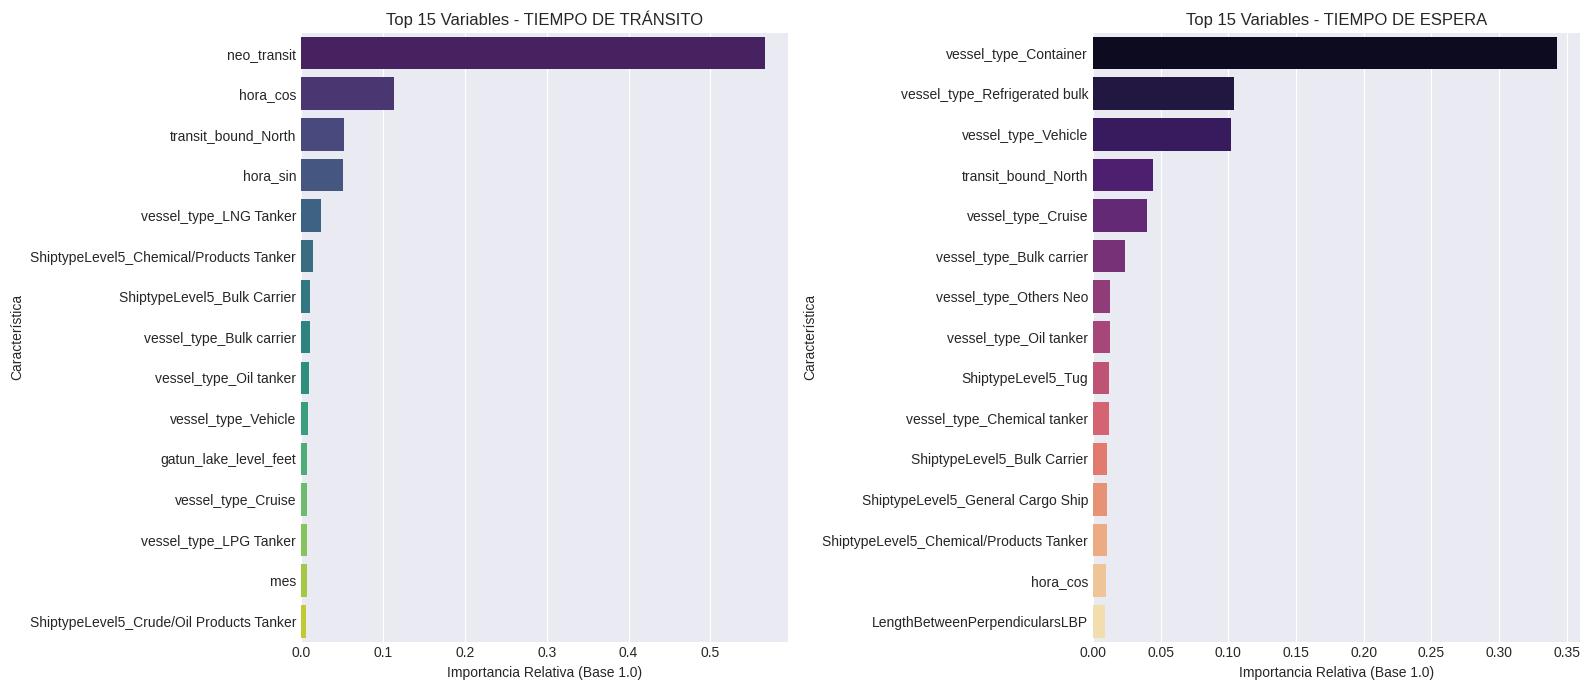


--- TOP 5 VARIABLES PARA TRÁNSITO ---
        Característica  Importancia
           neo_transit     0.566236
              hora_cos     0.113738
   transit_bound_North     0.052165
              hora_sin     0.050937
vessel_type_LNG Tanker     0.024806

--- TOP 5 VARIABLES PARA ESPERA ---
               Característica  Importancia
        vessel_type_Container     0.342644
vessel_type_Refrigerated bulk     0.103983
          vessel_type_Vehicle     0.102106
          transit_bound_North     0.044637
           vessel_type_Cruise     0.039849

Los resultados de importancia de características han sido exportados a:
- 'feature_importance_transit.csv'
- 'feature_importance_waiting.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

# --- ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ---

print("Evaluando importancia de variables para 'transit_time'...")
# Usamos un Random Forest rápido para extraer las importancias
xgbr_transit = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgbr_transit.fit(X_train, y_train['transit_time'])

# Guardamos las importancias en un DataFrame y lo ordenamos
importancias_transit = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': xgbr_transit.feature_importances_
}).sort_values(by='Importancia', ascending=False)


print("Evaluando importancia de variables para 'waiting_time'...")
xgbr_waiting = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgbr_waiting.fit(X_train, y_train['waiting_time'])

importancias_waiting = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': xgbr_waiting.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# --- VISUALIZACIÓN ---
# Crear un gráfico de barras con el "Top 15" de variables para cada variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico para Tránsito
sns.barplot(data=importancias_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Variables - TIEMPO DE TRÁNSITO')
axes[0].set_xlabel('Importancia Relativa (Base 1.0)')

# Gráfico para Espera
sns.barplot(data=importancias_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Variables - TIEMPO DE ESPERA')
axes[1].set_xlabel('Importancia Relativa (Base 1.0)')

plt.tight_layout()
plt.show()

# Imprimir el resumen en texto
print("\n--- TOP 5 VARIABLES PARA TRÁNSITO ---")
print(importancias_transit.head(5).to_string(index=False))

print("\n--- TOP 5 VARIABLES PARA ESPERA ---")
print(importancias_waiting.head(5).to_string(index=False))

# --- EXPORTAR A CSV ---
importancias_transit.to_csv('feature_importance_transit_XGBRegressor.csv', index=False)
importancias_waiting.to_csv('feature_importance_waiting_XGBRegressor.csv', index=False)

print("\nLos resultados de importancia de características han sido exportados a:")
print("- 'feature_importance_transit.csv'")
print("- 'feature_importance_waiting.csv'")

##### **Entrenamiento del modelo - XGBRegressor**

In [ ]:
import pandas as pd
import numpy as np

# Asegurarnos de que las columnas son formato fecha (por si acaso)
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])

# 1. ORDENAMIENTO CRONOLÓGICO (Vital para el rolling window)
df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

# 2. INGENIERÍA TEMPORAL (Mes y Día de la semana)
df['mes'] = df['time_at_entrance'].dt.month
df['dia_semana'] = df['time_at_entrance'].dt.dayofweek # 0=Lunes, 6=Domingo (Ayuda a ver patrones de fin de semana)

# 4. INGENIERÍA DE VARIABLES CÍCLICAS (Hora del día)
df['hora'] = df['time_at_entrance'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# 5. NUEVA SELECCIÓN DE CARACTERÍSTICAS (X)
# Observa que hemos añadido 'mes', 'dia_semana', 'llegadas_ultimas_24h' y 'llegadas_ultimas_48h'
features = [
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]



X = df[features].copy()
y = df[['transit_time', 'waiting_time']]

# 6. ONE-HOT ENCODING DE CATEGORÍAS
columnas_categoricas = ['vessel_type', 'transit_bound', 'MainEngineType', 'ShiptypeLevel5']
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

# 7. SPLIT CRONOLÓGICO (80% Entrenamiento / 20% Prueba)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print(f"--- Dataset Final Preparado ---")
print(f"Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h, clima y nivel del lago Gatún")
print(f"Dimensiones de X_train: {X_train.shape}")

--- Dataset Final Preparado ---
Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h, clima y nivel del lago Gatún
Dimensiones de X_train: (30576, 104)


In [ ]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Instanciamos el modelo base (XGBoost)
xgb_base = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,       # Tasa de aprendizaje ajustada para 1000 árboles
    subsample=0.8,            # Usa el 80% de los datos en cada árbol
    colsample_bytree=0.8,     # Usa el 80% de las características en cada árbol
    n_jobs=-1,
    random_state=42
)

# 2. Envolvemos en MultiOutputRegressor
# Esto entrenará internamente un XGBoost para Tránsito y otro para Espera
model_xgbr = MultiOutputRegressor(xgb_base)

# 3. ENTRENAMIENTO
print("Entrenando XGBoost... (esto puede tardar unos minutos)")
model_xgbr.fit(X_train, y_train)

# 4. PREDICCIÓN
y_pred = model_xgbr.predict(X_test)

# Convertimos a DataFrame para facilitar la comparación
y_pred_xgbr = pd.DataFrame(y_pred, columns=['pred_transit', 'pred_waiting'], index=y_test.index)

# Evaluar métricas
print("MAE Tránsito:", mean_absolute_error(y_test['transit_time'], y_pred[:, 0]))
print("MAE Espera:", mean_absolute_error(y_test['waiting_time'], y_pred[:, 1]))

Entrenando XGBoost... (esto puede tardar unos minutos)
MAE Tránsito: 0.9863746982497121
MAE Espera: 15.280977415461894


##### **Resultados del modelo**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# Cálculo de errores
mae_transit = mean_absolute_error(y_test['transit_time'], y_pred_xgbr['pred_transit'])
mae_waiting = mean_absolute_error(y_test['waiting_time'], y_pred_xgbr['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y_test['transit_time'], y_pred_xgbr['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y_test['waiting_time'], y_pred_xgbr['pred_waiting']))

r2_transit = r2_score(y_test['transit_time'], y_pred_xgbr['pred_transit'])
r2_waiting = r2_score(y_test['waiting_time'], y_pred_xgbr['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y_test['transit_time'], y_pred_xgbr['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y_test['waiting_time'], y_pred_xgbr['pred_waiting'])

print(f"\n--- RESULTADOS ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")
print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# Comparativa rápida: Real vs Predicho
comparativa = pd.concat([y_test.head(10), y_pred_xgbr.head(10)], axis=1)
print("\nPrimeras 10 predicciones vs Realidad:")
print(comparativa)



--- RESULTADOS ---
Error Medio Absoluto en Tránsito (MAE): 0.99 horas (59 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.44 horas (86 minutos)
R2 en Tránsito: 0.47
MAPE en Tránsito: 10.75%

Error Medio Absoluto en Espera (MAE): 15.28 horas (917 minutos)
Error Cuadrático Medio en Espera (RMSE): 21.96 horas (1318 minutos)
R2 en Espera: 0.20
MAPE en Espera: 132.01%

Primeras 10 predicciones vs Realidad:
       transit_time  waiting_time  pred_transit  pred_waiting
30576      7.791944     22.166667      8.970225     67.094666
30577      8.731667      2.000000      8.876972     15.859819
30578      9.424167     22.833333      8.745021     26.384497
30579      9.159444     70.500000      8.829156     63.684319
30580      8.600833     24.500000      8.683231     30.716192
30581      8.047222     15.333333      8.446307     34.924717
30582      8.000278     18.166667      7.254305     29.014553
30583      7.869722      7.333333      7.254305     29.014553
30584      8.166667      1.500

##### **Predicciones del modelo y resultados para todo el conjunto de datos - XGBR Boost**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# 1. HACER PREDICCIONES SOBRE TODO EL DATASET (X)
# Cambia 'model' por el nombre real de la variable de tu model entrenado
predicciones_totales = model_xgbr.predict(X)
y_pred_df_all_xgbr = pd.DataFrame(predicciones_totales, columns=['pred_transit', 'pred_waiting'])

# 2. CALCULAR ERRORES GLOBALES (Toda la base de datos)
mae_transit = mean_absolute_error(y['transit_time'], y_pred_df_all_xgbr['pred_transit'])
mae_waiting = mean_absolute_error(y['waiting_time'], y_pred_df_all_xgbr['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y['transit_time'], y_pred_df_all_xgbr['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y['waiting_time'], y_pred_df_all_xgbr['pred_waiting']))

r2_transit = r2_score(y['transit_time'], y_pred_df_all_xgbr['pred_transit'])
r2_waiting = r2_score(y['waiting_time'], y_pred_df_all_xgbr['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y['transit_time'], y_pred_df_all_xgbr['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y['waiting_time'], y_pred_df_all_xgbr['pred_waiting'])

print(f"\n--- RESULTADOS GLOBALES (TODO EL DATASET) ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# 3. EXTRAER CONTEXTO Y UNIR TODO
columnas_contexto = ['imo', 'time_at_entrance',
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]

df_contexto = df[columnas_contexto].reset_index(drop=True)
y_real = y.reset_index(drop=True)
y_pred = y_pred_df_all_xgbr.reset_index(drop=True)

# Unimos las 3 partes: Contexto + Valores Reales + Predicciones completas
comparativa = pd.concat([df_contexto, y_real, y_pred], axis=1)

print("\nMuestra de las predicciones vs Realidad (con contexto):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comparativa.head(10)) # Muestra los primeros 10 para no saturar la pantalla
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# OPCIONAL: Exportar el conjunto de datos completo a CSV para analizarlo
comparativa.to_csv('Resultados_XGBoost.csv', index=False)


--- RESULTADOS GLOBALES (TODO EL DATASET) ---
Error Medio Absoluto en Tránsito (MAE): 0.69 horas (42 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.02 horas (61 minutos)
R2 en Tránsito: 0.73
MAPE en Tránsito: 7.82%

Error Medio Absoluto en Espera (MAE): 11.85 horas (711 minutos)
Error Cuadrático Medio en Espera (RMSE): 16.81 horas (1008 minutos)
R2 en Espera: 0.52
MAPE en Espera: 600.57%

Muestra de las predicciones vs Realidad (con contexto):
       imo    time_at_entrance      vessel_type  neo_transit transit_bound  LengthBetweenPerpendicularsLBP MainEngineType  mes  dia_semana  hora_sin      hora_cos                   ShiptypeLevel5  gatun_lake_level_feet  temperature_2m (°c)  relative_humidity_2m (%)  vapour_pressure_deficit (kpa)  wind_gusts_10m (km/h)  wind_speed_10m (km/h)  transit_time  waiting_time  pred_transit  pred_waiting
0  9717292 2019-01-01 00:29:36  Chemical tanker            0         North                          176.00            Oil    1           1  0.000

#### **Modelo de ML usando GradientBoostingRegressor**

In [ ]:
import pandas as pd
import numpy as np

# Asegurarnos de que las columnas son formato fecha (por si acaso)
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])

# 1. ORDENAMIENTO CRONOLÓGICO (Vital para el rolling window)
df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

# 2. INGENIERÍA TEMPORAL (Mes y Día de la semana)
df['mes'] = df['time_at_entrance'].dt.month
df['dia_semana'] = df['time_at_entrance'].dt.dayofweek # 0=Lunes, 6=Domingo (Ayuda a ver patrones de fin de semana)

# 4. INGENIERÍA DE VARIABLES CÍCLICAS (Hora del día)
df['hora'] = df['time_at_entrance'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# 5. NUEVA SELECCIÓN DE CARACTERÍSTICAS (X)
# Observa que hemos añadido 'mes', 'dia_semana', 'llegadas_ultimas_24h' y 'llegadas_ultimas_48h'
features = [
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]



X = df[features].copy()
y = df[['transit_time', 'waiting_time']]

# 6. ONE-HOT ENCODING DE CATEGORÍAS
columnas_categoricas = ['vessel_type', 'transit_bound', 'MainEngineType', 'ShiptypeLevel5']
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

# 7. SPLIT CRONOLÓGICO (80% Entrenamiento / 20% Prueba)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print(f"--- Dataset Final Preparado ---")
print(f"Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h, clima y nivel del lago Gatún")
print(f"Dimensiones de X_train: {X_train.shape}")

--- Dataset Final Preparado ---
Nuevas variables agregadas: mes, dia_semana, llegadas_ultimas_24h, llegadas_ultimas_48h, clima y nivel del lago Gatún
Dimensiones de X_train: (30576, 104)


##### **Ingenería de Features - Gradient Boosting Regressor**

Evaluando importancia de variables para 'transit_time'...
Evaluando importancia de variables para 'waiting_time'...


/tmp/ipykernel_7130/2499329798.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
/tmp/ipykernel_7130/2499329798.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')


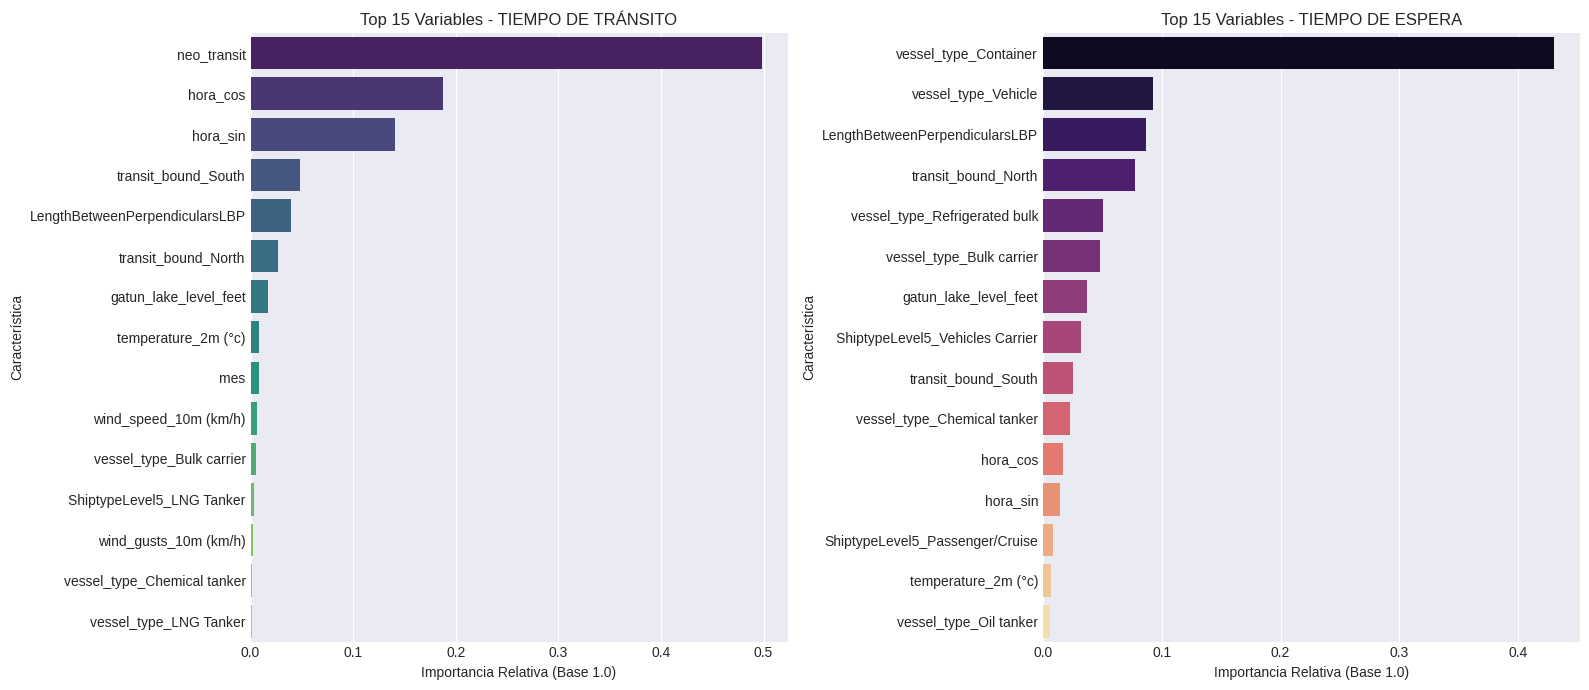


--- TOP 5 VARIABLES PARA TRÁNSITO ---
                Característica  Importancia
                   neo_transit     0.498458
                      hora_cos     0.187879
                      hora_sin     0.140439
           transit_bound_South     0.048112
LengthBetweenPerpendicularsLBP     0.038989

--- TOP 5 VARIABLES PARA ESPERA ---
                Característica  Importancia
         vessel_type_Container     0.430442
           vessel_type_Vehicle     0.092804
LengthBetweenPerpendicularsLBP     0.086620
           transit_bound_North     0.077800
 vessel_type_Refrigerated bulk     0.050784

Los resultados de importancia de características han sido exportados a:
- 'feature_importance_transit_gradientboost.csv'
- 'feature_importance_waiting_gradientboost.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor

# --- ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ---

print("Evaluando importancia de variables para 'transit_time'...")
# Usamos un Random Forest rápido para extraer las importancias
gb_transit = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_transit.fit(X_train, y_train['transit_time'])

# Guardamos las importancias en un DataFrame y lo ordenamos
importancias_transit = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': gb_transit.feature_importances_
}).sort_values(by='Importancia', ascending=False)


print("Evaluando importancia de variables para 'waiting_time'...")
gb_waiting = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_waiting.fit(X_train, y_train['waiting_time'])

importancias_waiting = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': gb_waiting.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# --- VISUALIZACIÓN ---
# Crear un gráfico de barras con el "Top 15" de variables para cada variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico para Tránsito
sns.barplot(data=importancias_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Variables - TIEMPO DE TRÁNSITO')
axes[0].set_xlabel('Importancia Relativa (Base 1.0)')

# Gráfico para Espera
sns.barplot(data=importancias_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Variables - TIEMPO DE ESPERA')
axes[1].set_xlabel('Importancia Relativa (Base 1.0)')

plt.tight_layout()
plt.show()

# Imprimir el resumen en texto
print("\n--- TOP 5 VARIABLES PARA TRÁNSITO ---")
print(importancias_transit.head(5).to_string(index=False))

print("\n--- TOP 5 VARIABLES PARA ESPERA ---")
print(importancias_waiting.head(5).to_string(index=False))

# --- EXPORTAR A CSV ---
importancias_transit.to_csv('feature_importance_transit_GradientBoostingRegressor.csv', index=False)
importancias_waiting.to_csv('feature_importance_waiting_GradientBoostingRegressor.csv', index=False)

print("\nLos resultados de importancia de características han sido exportados a:")
print("- 'feature_importance_transit_gradientboost.csv'")
print("- 'feature_importance_waiting_gradientboost.csv'")

##### **Entrenamiento del modelo - GradientBoostingRegressor**

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Instanciamos el modelo base (Gradient Boosting)
# Ajustamos parámetros similares a los anteriores para tener un punto de comparación
gb_base = GradientBoostingRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,         # Utiliza el 80% de las muestras por cada árbol para reducir el sobreajuste
    random_state=42
)

# 2. Envolvemos en MultiOutputRegressor
# Esto entrenará internamente un Gradient Boosting para Tránsito y otro para Espera
model_gb = MultiOutputRegressor(gb_base)

# 3. ENTRENAMIENTO
print("Entrenando Gradient Boosting... (esto puede tardar unos minutos)")
model_gb.fit(X_train, y_train)

# 4. PREDICCIÓN
y_pred_gb = model_gb.predict(X_test)

# Convertimos a DataFrame para facilitar la comparación
y_pred_gb = pd.DataFrame(y_pred_gb, columns=['pred_transit', 'pred_waiting'], index=y_test.index)

# (Opcional) Evaluar métricas usando los nombres de las columnas del DataFrame
print("MAE Tránsito:", mean_absolute_error(y_test['transit_time'], y_pred_gb['pred_transit']))
print("MAE Espera:", mean_absolute_error(y_test['waiting_time'], y_pred_gb['pred_waiting']))

Entrenando Gradient Boosting... (esto puede tardar unos minutos)
MAE Tránsito: 1.0043232968083453
MAE Espera: 15.453981537287866


##### **Resultados del modelo**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# Cálculo de errores
mae_transit = mean_absolute_error(y_test['transit_time'], y_pred_gb['pred_transit'])
mae_waiting = mean_absolute_error(y_test['waiting_time'], y_pred_gb['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y_test['transit_time'], y_pred_gb['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y_test['waiting_time'], y_pred_gb['pred_waiting']))

r2_transit = r2_score(y_test['transit_time'], y_pred_gb['pred_transit'])
r2_waiting = r2_score(y_test['waiting_time'], y_pred_gb['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y_test['transit_time'], y_pred_gb['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y_test['waiting_time'], y_pred_gb['pred_waiting'])

print(f"\n--- RESULTADOS ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# Comparativa rápida: Real vs Predicho
comparativa = pd.concat([y_test.head(10), y_pred_gb.head(10)], axis=1)
print("\nPrimeras 10 predicciones vs Realidad:")
print(comparativa)


--- RESULTADOS ---
Error Medio Absoluto en Tránsito (MAE): 1.00 horas (60 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.46 horas (88 minutos)
R2 en Tránsito: 0.46
MAPE en Tránsito: 10.96%

Error Medio Absoluto en Espera (MAE): 15.45 horas (927 minutos)
Error Cuadrático Medio en Espera (RMSE): 22.07 horas (1324 minutos)
R2 en Espera: 0.20
MAPE en Espera: 136.56%

Primeras 10 predicciones vs Realidad:
       transit_time  waiting_time  pred_transit  pred_waiting
30576      7.791944     22.166667      9.024754     64.677611
30577      8.731667      2.000000      8.884282     17.283215
30578      9.424167     22.833333      8.483590     27.862913
30579      9.159444     70.500000      8.641600     64.582929
30580      8.600833     24.500000      8.907236     28.535608
30581      8.047222     15.333333      8.568531     35.681520
30582      8.000278     18.166667      7.352265     30.849645
30583      7.869722      7.333333      7.352265     30.849645
30584      8.166667      1.500

##### **Predicciones del modelo y resultados para todo el conjunto de datos - GradientBoostingRegressor**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# 1. HACER PREDICCIONES SOBRE TODO EL DATASET (X)
# Cambia 'model' por el nombre real de la variable de tu model entrenado
predicciones_totales = model_gb.predict(X)
y_pred_df_all = pd.DataFrame(predicciones_totales, columns=['pred_transit', 'pred_waiting'])

# 2. CALCULAR ERRORES GLOBALES (Toda la base de datos)
mae_transit = mean_absolute_error(y['transit_time'], y_pred_df_all['pred_transit'])
mae_waiting = mean_absolute_error(y['waiting_time'], y_pred_df_all['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y['transit_time'], y_pred_df_all['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y['waiting_time'], y_pred_df_all['pred_waiting']))

r2_transit = r2_score(y['transit_time'], y_pred_df_all['pred_transit'])
r2_waiting = r2_score(y['waiting_time'], y_pred_df_all['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y['transit_time'], y_pred_df_all['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y['waiting_time'], y_pred_df_all['pred_waiting'])

print(f"\n--- RESULTADOS GLOBALES (TODO EL DATASET) ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit:.2f} horas ({mae_transit*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit:.2f} horas ({rmse_transit*60:.0f} minutos)")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting:.2f} horas ({mae_waiting*60:.0f} minutos)")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting:.2f} horas ({rmse_waiting*60:.0f} minutos)")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# 3. EXTRAER CONTEXTO Y UNIR TODO
columnas_contexto = ['imo', 'time_at_entrance',
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]
df_contexto = df[columnas_contexto].reset_index(drop=True)
y_real = y.reset_index(drop=True)
y_pred = y_pred_df_all.reset_index(drop=True)

# Unimos las 3 partes: Contexto + Valores Reales + Predicciones completas
comparativa = pd.concat([df_contexto, y_real, y_pred], axis=1)

print("\nMuestra de las predicciones vs Realidad (con contexto):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comparativa.head(10)) # Muestra los primeros 10 para no saturar la pantalla
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# OPCIONAL: Exportar el conjunto de datos completo a CSV para analizarlo
comparativa.to_csv('predicciones_completas_historico_gradientBoosting.csv', index=False)


--- RESULTADOS GLOBALES (TODO EL DATASET) ---
Error Medio Absoluto en Tránsito (MAE): 0.68 horas (41 minutos)
Error Cuadrático Medio en Tránsito (RMSE): 1.00 horas (60 minutos)
R2 en Tránsito: 0.74
MAPE en Tránsito: 7.75%

Error Medio Absoluto en Espera (MAE): 11.69 horas (701 minutos)
Error Cuadrático Medio en Espera (RMSE): 16.52 horas (991 minutos)
R2 en Espera: 0.54
MAPE en Espera: 583.10%

Muestra de las predicciones vs Realidad (con contexto):
       imo    time_at_entrance      vessel_type  neo_transit transit_bound  LengthBetweenPerpendicularsLBP MainEngineType  mes  dia_semana  hora_sin      hora_cos                   ShiptypeLevel5  gatun_lake_level_feet  temperature_2m (°c)  relative_humidity_2m (%)  vapour_pressure_deficit (kpa)  wind_gusts_10m (km/h)  wind_speed_10m (km/h)  transit_time  waiting_time  pred_transit  pred_waiting
0  9717292 2019-01-01 00:29:36  Chemical tanker            0         North                          176.00            Oil    1           1  0.0000

#### **Modelo de ML usando KNN REGRESSOR**

###### **Entrenamiento del modelo - KNN REGRESSOR**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Asegurarnos de que las columnas son formato fecha
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])

# 1. ORDENAMIENTO CRONOLÓGICO
df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

# 2. INGENIERÍA TEMPORAL
df['mes'] = df['time_at_entrance'].dt.month
df['dia_semana'] = df['time_at_entrance'].dt.dayofweek

# 3. INGENIERÍA DE VARIABLES CÍCLICAS
df['hora'] = df['time_at_entrance'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# 5. CARACTERÍSTICAS Y OBJETIVO
features = [
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]


X = df[features].copy()
y = df[['transit_time', 'waiting_time']]

# 6. ONE-HOT ENCODING
columnas_categoricas = ['vessel_type', 'transit_bound', 'MainEngineType', 'ShiptypeLevel5']
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

# 7. SPLIT CRONOLÓGICO
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# 8. ESCALADO

scaler = StandardScaler()

# AVISO IMPORTANTE: Hacemos FIT (aprender la media y varianza) SOLO en X_train
# para evitar fuga de datos del futuro. Luego Transform a ambos.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos de vuelta a DataFrames de Pandas (StandardScaler devuelve matrices numpy)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"--- Dataset Escalado y Preparado ---")
print(f"Dimensiones de X_train_scaled_df: {X_train_scaled_df.shape}")

--- Dataset Escalado y Preparado ---
Dimensiones de X_train_scaled_df: (30576, 104)


##### **Evaluación de modelo - KNN REGRESOR**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

print("\nEntrenando K-Nearest Neighbors...")
# n_neighbors=10 significa que buscará a los 10 barcos históricamente más similares
# (con clima, eslora y tipo parecidos) para promediar su tiempo
knn_model = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)
knn_model.fit(X_train_scaled_df, y_train)

# Predicciones y Evaluación
knn_preds = knn_model.predict(X_test_scaled_df)

print("--- RESULTADOS KNN (TRÁNSITO) ---")
print(f"MAE:  {mean_absolute_error(y_test['transit_time'], knn_preds[:, 0]):.2f} horas")
print(f"RMSE: {root_mean_squared_error(y_test['transit_time'], knn_preds[:, 0]):.2f} horas")
print(f"R2:   {r2_score(y_test['transit_time'], knn_preds[:, 0]):.2f}")

print("\n--- RESULTADOS KNN (ESPERA) ---")
print(f"MAE:  {mean_absolute_error(y_test['waiting_time'], knn_preds[:, 1]):.2f} horas")
print(f"RMSE: {root_mean_squared_error(y_test['waiting_time'], knn_preds[:, 1]):.2f} horas")
print(f"R2:   {r2_score(y_test['waiting_time'], knn_preds[:, 1]):.2f}")


Entrenando K-Nearest Neighbors...
--- RESULTADOS KNN (TRÁNSITO) ---
MAE:  1.01 horas
RMSE: 1.48 horas
R2:   0.45

--- RESULTADOS KNN (ESPERA) ---
MAE:  15.32 horas
RMSE: 22.13 horas
R2:   0.19


##### **Predicciones completas - KNN REGRESSOR**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# 1. ESCALAR TODO EL CONJUNTO DE DATOS (X)
# Usamos el 'scaler' que ya fue ajustado (fit) con X_train en el paso anterior
X_full_scaled = scaler.transform(X)
X_full_scaled_df = pd.DataFrame(X_full_scaled, columns=X.columns, index=X.index)

# 2. HACER PREDICCIONES SOBRE TODO EL DATASET CON KNN
print("\nGenerando predicciones de KNN para todo el histórico...")
knn_preds_all = knn_model.predict(X_full_scaled_df)

# Convertir las predicciones a DataFrame
y_pred_knn_df_all = pd.DataFrame(knn_preds_all, columns=['pred_transit', 'pred_waiting'])

# 3. CALCULAR ERRORES GLOBALES (Toda la base de datos)
mae_transit = mean_absolute_error(y['transit_time'], y_pred_knn_df_all['pred_transit'])
mae_waiting = mean_absolute_error(y['waiting_time'], y_pred_knn_df_all['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y['transit_time'], y_pred_knn_df_all['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y['waiting_time'], y_pred_knn_df_all['pred_waiting']))

r2_transit = r2_score(y['transit_time'], y_pred_knn_df_all['pred_transit'])
r2_waiting = r2_score(y['waiting_time'], y_pred_knn_df_all['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y['transit_time'], y_pred_knn_df_all['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y['waiting_time'], y_pred_knn_df_all['pred_waiting'])

print(f"\n--- RESULTADOS GLOBALES KNN (TODO EL DATASET) ---")
print(f"Error Medio Absoluto Tránsito (MAE): {mae_transit:.2f} horas")
print(f"Error Cuadrático Medio Tránsito (RMSE): {rmse_transit:.2f} horas")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto Espera (MAE): {mae_waiting:.2f} horas")
print(f"Error Cuadrático Medio Espera (RMSE): {rmse_waiting:.2f} horas")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# 4. EXTRAER CONTEXTO Y UNIR TODO
columnas_contexto = ['imo', 'time_at_entrance',
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]
df_contexto = df[columnas_contexto].reset_index(drop=True)
y_real = y.reset_index(drop=True)
y_pred_knn = y_pred_knn_df_all.reset_index(drop=True)

# Unimos las 3 partes: Contexto + Valores Reales + Predicciones de KNN
comparativa_knn = pd.concat([df_contexto, y_real, y_pred_knn], axis=1)

print("\nMuestra de las predicciones KNN vs Realidad (con contexto):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comparativa_knn.head(10))
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# OPCIONAL: Exportar el conjunto de datos a CSV
comparativa_knn.to_csv('predicciones_completas_KNN.csv', index=False)


Generando predicciones de KNN para todo el histórico...

--- RESULTADOS GLOBALES KNN (TODO EL DATASET) ---
Error Medio Absoluto Tránsito (MAE): 0.88 horas
Error Cuadrático Medio Tránsito (RMSE): 1.28 horas
R2 en Tránsito: 0.57
MAPE en Tránsito: 9.82%

Error Medio Absoluto Espera (MAE): 14.01 horas
Error Cuadrático Medio Espera (RMSE): 19.80 horas
R2 en Espera: 0.33
MAPE en Espera: 723.16%

Muestra de las predicciones KNN vs Realidad (con contexto):
       imo    time_at_entrance      vessel_type  neo_transit transit_bound  LengthBetweenPerpendicularsLBP MainEngineType  mes  dia_semana  hora_sin      hora_cos                   ShiptypeLevel5  gatun_lake_level_feet  temperature_2m (°c)  relative_humidity_2m (%)  vapour_pressure_deficit (kpa)  wind_gusts_10m (km/h)  wind_speed_10m (km/h)  transit_time  waiting_time  pred_transit  pred_waiting
0  9717292 2019-01-01 00:29:36  Chemical tanker            0         North                          176.00            Oil    1           1  0.00000

#### **Modelo de ML usando DE LIGHTGBM**

###### **Entrenamiento del modelo - LIGHTGBM**

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero añadiendo un pequeño epsilon o filtrando valores
    # Aquí, se reemplazan los 0s en y_true con NaN para excluirlos del cálculo
    # o se usa un epsilon si se prefiere una aproximación
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Manejar el caso de y_true = 0 para evitar divisiones por cero.
    # Una estrategia común es reemplazar los ceros con un valor muy pequeño (epsilon)
    # o excluirlos del cálculo. Aquí optaremos por excluir (NaN)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Si todos los valores reales son cero, MAPE no es definible

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# 0. LIMPIEZA DE NOMBRES DE COLUMNAS PARA LIGHTGBM
# A LightGBM no le gustan caracteres especiales (", [, ], {, }, :) en los nombres.
# Los cambiamos por guiones bajos ('_').
limpiar_nombre = lambda x: re.sub(r'[",\[\]{}:]', '_', str(x))

X.columns = [limpiar_nombre(col) for col in X.columns]
X_train.columns = [limpiar_nombre(col) for col in X_train.columns]
X_test.columns = [limpiar_nombre(col) for col in X_test.columns]

# 1. ENTRENAMIENTO CON LIGHTGBM
print("\nEntrenando LightGBM...")

lgbm_base = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos del procesador
)

# Envolvemos para predecir múltiples variables a la vez (transit y waiting)
model_lgbm = MultiOutputRegressor(lgbm_base)

# Entrenamos usando tus datos X_train normales (sin escalar)
model_lgbm.fit(X_train, y_train)

# 2. PREDICCIÓN SOBRE TODO EL CONJUNTO DE DATOS
print("Generando predicciones con LightGBM para todo el histórico...")

# Predecimos usando la 'X' completa original
lgbm_preds_all = model_lgbm.predict(X)

# Convertir las predicciones a DataFrame
y_pred_lgbm_df_all = pd.DataFrame(lgbm_preds_all, columns=['pred_transit', 'pred_waiting'])

# 3. CALCULAR MÉTRICAS GLOBALES
mae_transit = mean_absolute_error(y['transit_time'], y_pred_lgbm_df_all['pred_transit'])
mae_waiting = mean_absolute_error(y['waiting_time'], y_pred_lgbm_df_all['pred_waiting'])

rmse_transit = np.sqrt(mean_squared_error(y['transit_time'], y_pred_lgbm_df_all['pred_transit']))
rmse_waiting = np.sqrt(mean_squared_error(y['waiting_time'], y_pred_lgbm_df_all['pred_waiting']))

r2_transit = r2_score(y['transit_time'], y_pred_lgbm_df_all['pred_transit'])
r2_waiting = r2_score(y['waiting_time'], y_pred_lgbm_df_all['pred_waiting'])

# Cálculo de MAPE
mape_transit = mean_absolute_percentage_error(y['transit_time'], y_pred_lgbm_df_all['pred_transit'])
mape_waiting = mean_absolute_percentage_error(y['waiting_time'], y_pred_lgbm_df_all['pred_waiting'])

print(f"\n--- RESULTADOS GLOBALES LIGHTGBM (TODO EL DATASET) ---")
print(f"Error Medio Absoluto Tránsito (MAE): {mae_transit:.2f} horas")
print(f"Error Cuadrático Medio Tránsito (RMSE): {rmse_transit:.2f} horas")
print(f"R2 en Tránsito: {r2_transit:.2f}")
print(f"MAPE en Tránsito: {mape_transit:.2f}%")

print(f"\nError Medio Absoluto Espera (MAE): {mae_waiting:.2f} horas")
print(f"Error Cuadrático Medio Espera (RMSE): {rmse_waiting:.2f} horas")
print(f"R2 en Espera: {r2_waiting:.2f}")
print(f"MAPE en Espera: {mape_waiting:.2f}%")

# 4. UNIR CON EL CONTEXTO Y MOSTRAR RESULTADOS
columnas_contexto = ['imo', 'time_at_entrance',
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]


df_contexto = df[columnas_contexto].reset_index(drop=True)
y_real = y.reset_index(drop=True)
y_pred_lgbm = y_pred_lgbm_df_all.reset_index(drop=True)

# Unimos las 3 partes: Contexto + Valores Reales + Predicciones LightGBM
comparativa_lgbm = pd.concat([df_contexto, y_real, y_pred_lgbm], axis=1)

print("\nMuestra de las predicciones LIGHTGBM vs Realidad (con contexto):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comparativa_lgbm.head(10))
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# OPCIONAL: Exportar el conjunto de datos a CSV
comparativa_lgbm.to_csv('predicciones_completas_LightGBM.csv', index=False)


Entrenando LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1191
[LightGBM] [Info] Number of data points in the train set: 30576, number of used features: 55
[LightGBM] [Info] Start training from score 8.513260
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

Extrayendo importancia de variables desde LightGBM...


/tmp/ipykernel_7130/3218113315.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_lgbm_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
/tmp/ipykernel_7130/3218113315.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_lgbm_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')


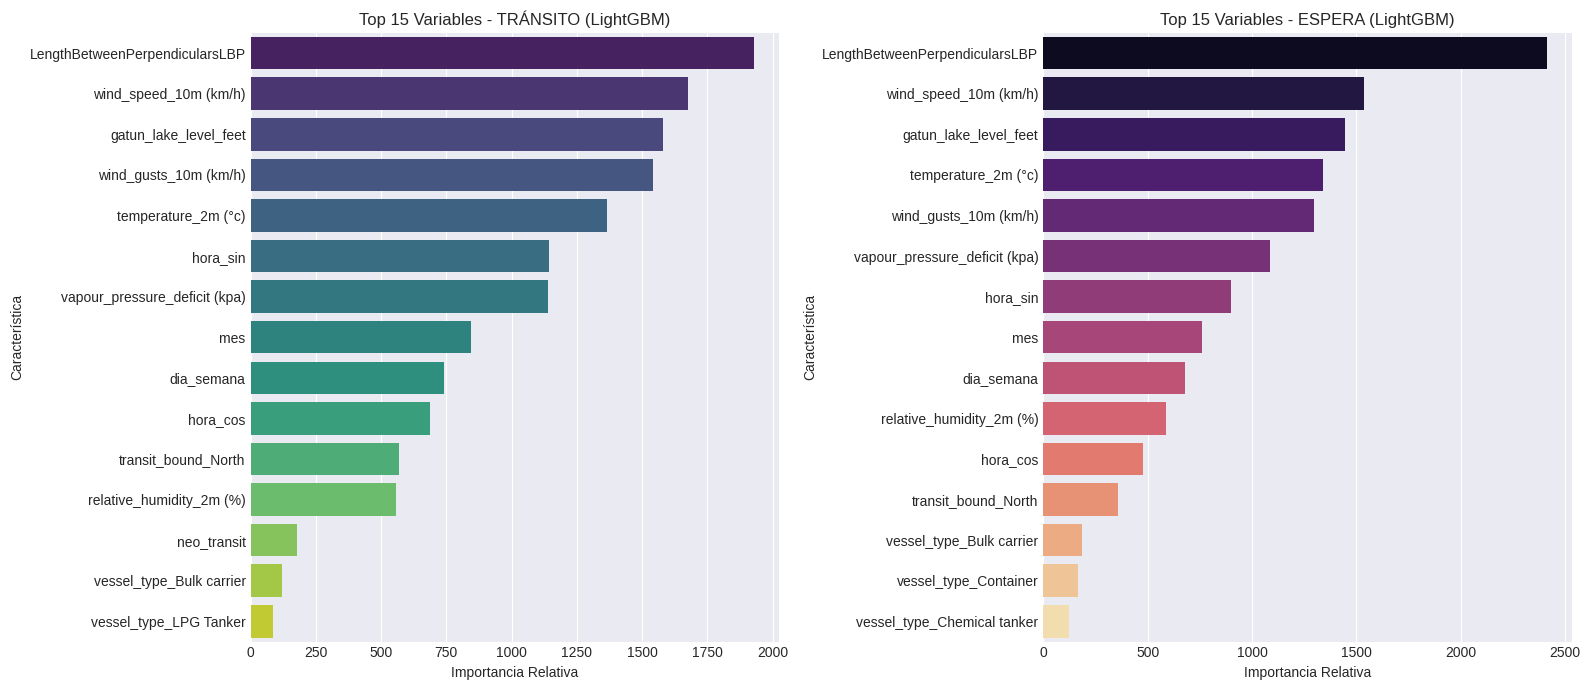

Importancias exportadas a CSV.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Extrayendo importancia de variables desde LightGBM...")

# Como usamos MultiOutputRegressor, el modelo interno para 'transit' es el estimador 0
# y el modelo interno para 'waiting' es el estimador 1.
lgbm_transit = model_lgbm.estimators_[0]
lgbm_waiting = model_lgbm.estimators_[1]

# Extraemos las importancias para Tránsito
importancias_lgbm_transit = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': lgbm_transit.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Extraemos las importancias para Espera
importancias_lgbm_waiting = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': lgbm_waiting.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico para Tránsito (Top 15)
sns.barplot(data=importancias_lgbm_transit.head(15), x='Importancia', y='Característica', ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Variables - TRÁNSITO (LightGBM)')
axes[0].set_xlabel('Importancia Relativa')

# Gráfico para Espera (Top 15)
sns.barplot(data=importancias_lgbm_waiting.head(15), x='Importancia', y='Característica', ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Variables - ESPERA (LightGBM)')
axes[1].set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

# Exportar a CSV si lo deseas
importancias_lgbm_transit.to_csv('feature_importance_LGBM_transit.csv', index=False)
importancias_lgbm_waiting.to_csv('feature_importance_LGBM_waiting.csv', index=False)
print("Importancias exportadas a CSV.")

## Modelo de Redes Neuronales

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- 1. PREPARACIÓN DE DATOS PARA REDES NEURONALES ---

# Asegurarse de que las columnas son formato fecha (por si acaso)
df['time_at_entrance'] = pd.to_datetime(df['time_at_entrance'])

# 1. ORDENAMIENTO CRONOLÓGICO (Vital para el rolling window)
df = df.sort_values(by='time_at_entrance').reset_index(drop=True)

# 2. INGENIERÍA TEMPORAL (Mes y Día de la semana)
df['mes'] = df['time_at_entrance'].dt.month
df['dia_semana'] = df['time_at_entrance'].dt.dayofweek # 0=Lunes, 6=Domingo (Ayuda a ver patrones de fin de semana)

# 3. INGENIERÍA DE VARIABLES CÍCLICAS (Hora del día)
df['hora'] = df['time_at_entrance'].dt.hour
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# 4. SELECCIÓN DE CARACTERÍSTICAS (X) y OBJETIVO (y)
features = [
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]


X = df[features].copy()
y = df[['transit_time', 'waiting_time']]

# 5. ONE-HOT ENCODING DE CATEGORÍAS
columnas_categoricas = ['vessel_type', 'transit_bound', 'MainEngineType', 'ShiptypeLevel5']
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

# 6. SPLIT CRONOLÓGICO (80% Entrenamiento / 20% Prueba)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# 7. ESCALADO DE CARACTERÍSTICAS NUMÉRICAS
# Identificar columnas numéricas después del one-hot encoding
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

# Volver a asignar los datos escalados al DataFrame manteniendo las columnas originales
X_train[numeric_cols] = X_train_scaled
X_test[numeric_cols] = X_test_scaled

print(f"--- Dataset Preparado para Redes Neuronales ---")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")

# --- 2. DEFINICIÓN DEL MODELO DE RED NEURONAL ---
print("\nConstruyendo el modelo de Red Neuronal...")

model_nn = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)), # Capa de entrada y primera capa oculta
    layers.Dropout(0.3), # Dropout para regularización
    layers.Dense(128, activation='relu'), # Segunda capa oculta
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),  # Tercera capa oculta
    layers.Dense(2) # Capa de salida con 2 neuronas para 'transit_time' y 'waiting_time'
])

# --- 3. COMPILACIÓN DEL MODELO ---
model_nn.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

model_nn.summary()

# --- 4. ENTRENAMIENTO DEL MODELO ---
print("\nEntrenando la Red Neuronal... (esto puede tardar más)")
history = model_nn.fit(
    X_train, y_train,
    epochs=50, # Número de épocas, se puede ajustar
    batch_size=32, # Tamaño del lote
    validation_split=0.2, # 20% de los datos de entrenamiento para validación
    verbose=1 # Muestra el progreso del entrenamiento
)

# --- 5. EVALUACIÓN DEL MODELO EN EL CONJUNTO DE PRUEBA ---
print("\nEvaluando el modelo en el conjunto de prueba...")
loss, mae, mse = model_nn.evaluate(X_test, y_test, verbose=0)
print(f"Loss (MSE) en Test: {loss:.2f}")
print(f"MAE en Test: {mae:.2f}")

# Realizar predicciones
y_pred_nn = model_nn.predict(X_test)
y_pred_nn_df = pd.DataFrame(y_pred_nn, columns=['pred_transit', 'pred_waiting'], index=y_test.index)

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

# Cálculo de métricas adicionales para el conjunto de prueba
mae_transit_test = mean_absolute_error(y_test['transit_time'], y_pred_nn_df['pred_transit'])
mae_waiting_test = mean_absolute_error(y_test['waiting_time'], y_pred_nn_df['pred_waiting'])

rmse_transit_test = np.sqrt(mean_squared_error(y_test['transit_time'], y_pred_nn_df['pred_transit']))
rmse_waiting_test = np.sqrt(mean_squared_error(y_test['waiting_time'], y_pred_nn_df['pred_waiting']))

r2_transit_test = r2_score(y_test['transit_time'], y_pred_nn_df['pred_transit'])
r2_waiting_test = r2_score(y_test['waiting_time'], y_pred_nn_df['pred_waiting'])

mape_transit_test = mean_absolute_percentage_error(y_test['transit_time'], y_pred_nn_df['pred_transit'])
mape_waiting_test = mean_absolute_percentage_error(y_test['waiting_time'], y_pred_nn_df['pred_waiting'])

print(f"\n--- RESULTADOS DEL MODELO DE RED NEURONAL (CONJUNTO DE PRUEBA) ---")
print(f"Error Medio Absoluto en Tránsito (MAE): {mae_transit_test:.2f} horas")
print(f"Error Cuadrático Medio en Tránsito (RMSE): {rmse_transit_test:.2f} horas")
print(f"R2 en Tránsito: {r2_transit_test:.2f}")
print(f"MAPE en Tránsito: {mape_transit_test:.2f}%")

print(f"\nError Medio Absoluto en Espera (MAE): {mae_waiting_test:.2f} horas")
print(f"Error Cuadrático Medio en Espera (RMSE): {rmse_waiting_test:.2f} horas")
print(f"R2 en Espera: {r2_waiting_test:.2f}")
print(f"MAPE en Espera: {mape_waiting_test:.2f}%")

# --- 6. PREDICCIONES GLOBALES Y RESULTADOS FINALES ---
print("\nGenerando predicciones con la Red Neuronal para todo el histórico...")

# Escalar el conjunto completo de X para predicciones globales
X_full_scaled = X.copy() # Hacemos una copia para no modificar X original (con one-hot ya aplicado)
X_full_scaled[numeric_cols] = scaler.transform(X[numeric_cols])

# Realizar predicciones sobre el conjunto X completo
predicciones_totales_nn = model_nn.predict(X_full_scaled)
y_pred_nn_all_df = pd.DataFrame(predicciones_totales_nn, columns=['pred_transit', 'pred_waiting'])

# Calcular errores globales (Toda la base de datos)
mae_transit_all = mean_absolute_error(y['transit_time'], y_pred_nn_all_df['pred_transit'])
mae_waiting_all = mean_absolute_error(y['waiting_time'], y_pred_nn_all_df['pred_waiting'])

rmse_transit_all = np.sqrt(mean_squared_error(y['transit_time'], y_pred_nn_all_df['pred_transit']))
rmse_waiting_all = np.sqrt(mean_squared_error(y['waiting_time'], y_pred_nn_all_df['pred_waiting']))

r2_transit_all = r2_score(y['transit_time'], y_pred_nn_all_df['pred_transit'])
r2_waiting_all = r2_score(y['waiting_time'], y_pred_nn_all_df['pred_waiting'])

mape_transit_all = mean_absolute_percentage_error(y['transit_time'], y_pred_nn_all_df['pred_transit'])
mape_waiting_all = mean_absolute_percentage_error(y['waiting_time'], y_pred_nn_all_df['pred_waiting'])

print(f"\n--- RESULTADOS GLOBALES DE RED NEURONAL (TODO EL DATASET) ---")
print(f"Error Medio Absoluto Tránsito (MAE): {mae_transit_all:.2f} horas")
print(f"Error Cuadrático Medio Tránsito (RMSE): {rmse_transit_all:.2f} horas")
print(f"R2 en Tránsito: {r2_transit_all:.2f}")
print(f"MAPE en Tránsito: {mape_transit_all:.2f}%")

print(f"\nError Medio Absoluto Espera (MAE): {mae_waiting_all:.2f} horas")
print(f"Error Cuadrático Medio Espera (RMSE): {rmse_waiting_all:.2f} horas")
print(f"R2 en Espera: {r2_waiting_all:.2f}")
print(f"MAPE en Espera: {mape_waiting_all:.2f}%")

# 7. UNIR CON EL CONTEXTO Y MOSTRAR RESULTADOS
columnas_contexto = ['imo', 'time_at_entrance',
    'vessel_type', 'neo_transit', 'transit_bound',
    'LengthBetweenPerpendicularsLBP', 'MainEngineType',
    'mes', 'dia_semana', 'hora_sin', 'hora_cos',
    'ShiptypeLevel5',
    'gatun_lake_level_feet',
    'temperature_2m (°c)', 'relative_humidity_2m (%)',
    'vapour_pressure_deficit (kpa)', 'wind_gusts_10m (km/h)',
    'wind_speed_10m (km/h)'
]


df_contexto = df[columnas_contexto].reset_index(drop=True)
y_real = y.reset_index(drop=True)
y_pred = y_pred_nn_all_df.reset_index(drop=True)

# Unimos las 3 partes: Contexto + Valores Reales + Predicciones de la Red Neuronal
comparativa_nn = pd.concat([df_contexto, y_real, y_pred], axis=1)

print("\nMuestra de las predicciones de Red Neuronal vs Realidad (con contexto):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comparativa_nn.head(10))
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

# OPCIONAL: Exportar el conjunto de datos a CSV
comparativa_nn.to_csv('predicciones_completas_NeuralNetwork.csv', index=False)

--- Dataset Preparado para Redes Neuronales ---
Dimensiones de X_train: (30576, 104)
Dimensiones de y_train: (30576, 2)

Construyendo el modelo de Red Neuronal...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,162 (266.26 KB)

 Trainable params: 68,162 (266.26 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando la Red Neuronal... (esto puede tardar más)
Epoch 1/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 243.8515 - mae: 8.8427 - mse: 243.8515 - val_loss: 230.5093 - val_mae: 8.1572 - val_mse: 230.5093
Epoch 2/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 223.3704 - mae: 8.3401 - mse: 223.3704 - val_loss: 232.1161 - val_mae: 8.1061 - val_mse: 232.1161
Epoch 3/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 219.9638 - mae: 8.2523 - mse: 219.9638 - val_loss: 231.0894 - val_mae: 8.0664 - val_mse: 231.0894
Epoch 4/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 218.4576 - mae: 8.2080 - mse: 218.4576 - val_loss: 235.7422 - val_mae: 7.9609 - val_mse: 235.7422
Epoch 5/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 218.3929 - mae: 8.1786 - mse: 218.3929 - val_loss: 228.4465 - val_mae: 8.2301 - val_mse: 228.4465
Epoch 6/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 216.3284 - mae: 8.1337 - mse: 216.3284 - val_loss: 231.6093 - val_mae: 7.9676 - val_mse: 231.60

In [ ]:
import pandas as pd

# --- Métrica de Tránsito ---
metrics_transit = {
    'Random Forest': {
        'MAE': 0.90,
        'RMSE': 1.31,
        'MAPE': 10.11,
        'R2': 0.55
    },
    'XGBoost': {
        'MAE': 0.69,
        'RMSE': 1.02,
        'MAPE': 7.82,
        'R2': 0.73
    },
    'Gradient Boosting': {
        'MAE': 0.68,
        'RMSE': 1.00,
        'MAPE': 7.75,
        'R2': 0.74
    },
    'KNN Regressor': {
        'MAE': 0.88,
        'RMSE': 1.28,
        'MAPE': 9.82,
        'R2': 0.57
    },
    'LightGBM': {
        'MAE': 0.80,
        'RMSE': 1.17,
        'MAPE': 8.95,
        'R2': 0.64
    },
    'Red Neuronal': {
        'MAE': 1.00,
        'RMSE': 1.42,
        'MAPE': 11.23,
        'R2': 0.47
    }
}

# --- Métrica de Espera ---
metrics_waiting = {
    'Random Forest': {
        'MAE': 14.83,
        'RMSE': 20.73,
        'MAPE': 835.63,
        'R2': 0.27
    },
    'XGBoost': {
        'MAE': 11.85,
        'RMSE': 16.81,
        'MAPE': 600.57,
        'R2': 0.52
    },
    'Gradient Boosting': {
        'MAE': 11.69,
        'RMSE': 16.52,
        'MAPE': 583.10,
        'R2': 0.54
    },
    'KNN Regressor': {
        'MAE': 14.01,
        'RMSE': 19.80,
        'MAPE': 708.90,
        'R2': 0.34
    },
    'LightGBM': {
        'MAE': 13.35,
        'RMSE': 18.75,
        'MAPE': 706.90,
        'R2': 0.40
    },
    'Red Neuronal': {
        'MAE': 14.28,
        'RMSE': 20.25,
        'MAPE': 753.44,
        'R2': 0.30
    }
}

# Convertir a DataFrames
df_transit = pd.DataFrame(metrics_transit).T
df_waiting = pd.DataFrame(metrics_waiting).T

# Unir los resultados en un solo DataFrame
comparison_df = pd.concat([df_transit.add_suffix(' (Tránsito)'), df_waiting.add_suffix(' (Espera)')], axis=1)

print("\n--- Resumen Comparativo de Modelos ---")
display(comparison_df.round(2))

# Exportar a CSV
comparison_df.to_csv('resumen_modelos.csv', index=True)
print("\nEl resumen comparativo ha sido exportado a 'resumen_modelos.csv'")


--- Resumen Comparativo de Modelos ---


,MAE (Tránsito),RMSE (Tránsito),MAPE (Tránsito),R2 (Tránsito),MAE (Espera),RMSE (Espera),MAPE (Espera),R2 (Espera)
Random Forest,0.90,1.31,10.11,0.55,14.83,20.73,835.63,0.27
XGBoost,0.69,1.02,7.82,0.73,11.85,16.81,600.57,0.52
Gradient Boosting,0.68,1.00,7.75,0.74,11.69,16.52,583.10,0.54
KNN Regressor,0.88,1.28,9.82,0.57,14.01,19.80,708.90,0.34
LightGBM,0.80,1.17,8.95,0.64,13.35,18.75,706.90,0.40
Red Neuronal,1.00,1.42,11.23,0.47,14.28,20.25,753.44,0.30



El resumen comparativo ha sido exportado a 'resumen_modelos.csv'
